
# Análisis Exploratorio de Datos (EDA) de Incendios

Este notebook realiza un análisis exploratorio de datos sobre incidentes de incendios.
Cargaremos los datos, realizaremos limpieza básica, analizaremos las distribuciones
de variables clave y visualizaremos patrones, incluyendo aspectos geoespaciales.


## 1. Configuración e Importación de Librerías

Importamos las librerías necesarias para el análisis y configuramos los estilos de visualización.

In [59]:
#! pip install calmap squarify geopandas shapely
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import chi2_contingency
import calmap
import math
import squarify
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import pandas as pd
from ipywidgets import interact, Dropdown, IntSlider, Output, VBox
from matplotlib.cm import get_cmap

In [4]:
# Configuraciones para matplotlib y seaborn
plt.style.use('ggplot') # Usar un estilo de gráfico agradable
plt.rcParams['figure.figsize'] = (12, 8) # Tamaño por defecto de las figuras
plt.rcParams['font.size'] = 14 # Tamaño por defecto de la fuente

# Opcionalmente, para una mejor visualización en notebooks (si no estás en un entorno como Colab que lo hace automáticamente)
# %matplotlib inline


## 2. Carga de Datos

Cargamos el archivo CSV que contiene los datos de incendios. Incluimos manejo básico de errores
para el caso de que el archivo no se encuentre. Intentamos con diferentes codificaciones si la primera falla.

In [9]:
file_path = '/content/Hist_inc.csv' # Asegúrate de que esta ruta sea correcta

try:
    # Intentar leer con codificación UTF-8 primero (la más común)
    df = pd.read_csv(file_path)
    print("Archivo leído exitosamente con codificación UTF-8.")

except UnicodeDecodeError:
    # Si falla UTF-8, intentar con 'latin-1'
    try:
        df = pd.read_csv(file_path, encoding='latin-1')
        print("Archivo leído exitosamente con codificación latin-1.")

    except Exception as e:
        # Si falla 'latin-1' o hay otro error al leer
        print(f"Error: No se pudo leer el archivo '{file_path}' con las codificaciones intentadas.")
        print(f"Detalle del error: {e}")
        df = None # Asegurarse de que df sea None si hay un error

except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no fue encontrado. Asegúrate de que el archivo esté en la ruta especificada.")
    df = None # Asegurarse de que df sea None si hay un error

except Exception as e:
    print(f"Ocurrió un error inesperado al leer el archivo: {e}")
    df = None # Asegurarse de que df sea None si hay un error

Archivo leído exitosamente con codificación latin-1.


<ipython-input-9-f84e5717492d>:11: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding='latin-1')


Archivo leído exitosamente.


## 3. Inspección Inicial de Datos

Si los datos se cargaron correctamente, realizamos una inspección inicial para entender su estructura,
tipos de datos, valores nulos y estadísticas descriptivas.

In [10]:
if df is not None:
    print("\n--- Primeras 5 filas del DataFrame ---")
    print(df.head())

    print("\n--- Información del DataFrame ---")
    df.info()

    print("\n--- Estadísticas Descriptivas de Columnas Numéricas ---")
    print(df.describe())

    print("\n--- Conteo de Valores Nulos por Columna ---")
    print(df.isnull().sum())

    print("\n--- Conteo de Filas Duplicadas ---")
    print(df.duplicated().sum())
else:
    print("\nNo se pudo cargar el DataFrame. No se realizará la inspección inicial.")



--- Primeras 5 filas del DataFrame ---
    AÑO  CONSECUTIV  CLAVE_INCE TIPO_ATENC IFAE    LATITUD    LONGITUD  \
0  2018       469.0  18-14-0469        NaN  NaN  22.711201 -103.821999   
1  2010         NaN  10-14-0002        NaN  NaN  20.768101 -103.927002   
2  2010         NaN  10-14-0003        NaN  NaN  20.775000 -103.871002   
3  2010         NaN  10-14-0004        NaN  NaN  20.795299 -103.799004   
4  2010         NaN  10-14-0005        NaN  NaN  20.375000 -104.120003   

   CLAVE_MUNI  ENTIDAD             MUNICIPIO  ... ALA_FIJA HELICOPTER  \
0        42.0  Jalisco   Huejuquilla el Alto  ...        0          0   
1         NaN  Jalisco  Ahualulco De Mercado  ...        0          0   
2         NaN  Jalisco  Ahualulco De Mercado  ...        0          0   
3         NaN  Jalisco             Amatítlan  ...        0          0   
4         NaN  Jalisco                 Ameca  ...        0          0   

  CANTIDAD INSTANCIAS  DRON INTERMUNIC  INTERMU_01 INTERESTAT INTERES_01  \


## 4. Limpieza y Preparación de Datos

Realizamos pasos de limpieza como manejar valores nulos, convertir tipos de datos
y renombrar columnas si es necesario para facilitar el análisis.

**Nota:** Ajusta los nombres de las columnas ('Fecha', 'Latitud', 'Longitud', etc.)
según los nombres reales en tu archivo CSV.


In [11]:
df.columns.unique()

Index(['AÑO', 'CONSECUTIV', 'CLAVE_INCE', 'TIPO_ATENC', 'IFAE', 'LATITUD',
       'LONGITUD', 'CLAVE_MUNI', 'ENTIDAD', 'MUNICIPIO', 'PREDIO_PAR', 'CAUSA',
       'CAUSA_ESPE', 'FECHA_INIC', 'Dia Inicio', 'FECHA_TERM', 'Día Termino',
       'Duración _dias', 'CATEGORIA_', 'DETECCION', 'LLEGADA', 'DURACION',
       'TIPO_INCEN', 'Tipo de Vegteacion', 'ZONA_BIOCL', 'REGIMEN_DE',
       'CLASIFICAC', 'ARBOLADO_A', 'RENUEVO', 'ARBUSTIVO', 'HERBACEO',
       'HOJARASCA', 'TOTAL_HA', 'Clasif_Por_Sup_Afectada', 'ANP', 'ANP_HA',
       'CATEGOR_01', 'TIPO_ANP', 'Superficie Salvada\t', 'CO2_EMITID',
       'CO2_EVITO_', 'COMBATIENT', 'COMBATI_01', 'COMBATI_02', 'SERVICIOS_',
       'PROTECCION', 'COMBRUR_NA', 'CONAFOR_OT', 'CONANP_OFI', 'CONANP_OTR',
       'SEDENA', 'SEMAR', 'GUARDIA_NA', 'OTRAS_INST', 'GOBIERNO_E',
       'PROTECC_01', 'GOBIERNO_M', 'PROTECC_02', 'VOLUNTARIO', 'PROPIETARI',
       'ONGS', 'SILVICULTO', 'SECTOR_PRI', 'APROVECHAM', 'TOTAL_COMB',
       'COSTO_ESTI', 'ALA_FIJA', 

In [12]:
if df is not None:
    # Renombrar columnas si es necesario (ejemplo: si los nombres tienen espacios o caracteres especiales)
    # df.rename(columns={'Nombre Columna Anterior': 'nombre_columna_nueva'}, inplace=True)
    # print("\nColumnas renombradas si fue necesario.")
    # print(df.columns) # Mostrar los nombres de las columnas después de renombrar

    # Convertir la columna de fecha de inicio a tipo datetime
    # Usando la columna 'FECHA_INIC'
    fecha_col = 'FECHA_INIC'
    if fecha_col in df.columns:
        try:
            df[fecha_col] = pd.to_datetime(df[fecha_col])
            print(f"\nColumna '{fecha_col}' convertida a datetime.")
        except Exception as e:
            print(f"\nError al convertir la columna '{fecha_col}' a datetime: {e}")
    else:
        print(f"\nColumna '{fecha_col}' no encontrada. No se realizó la conversión a datetime.")


    # Convertir columnas de latitud y longitud a tipo numérico
    # Usando las columnas 'LATITUD' y 'LONGITUD'
    coord_cols = ['LATITUD', 'LONGITUD']
    for col in coord_cols:
        if col in df.columns:
            # Intentar convertir a numérico, coercing errores a NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"Columna '{col}' convertida a numérico.")
        else:
            print(f"Columna '{col}' no encontrada.")

    # Eliminar columnas con un 10% o más de valores NaN
    threshold = 0.1  # Umbral del 10%
    nan_percentage = df.isnull().sum() / len(df)
    columns_to_drop = nan_percentage[nan_percentage >= threshold].index
    num_dropped_columns = len(columns_to_drop)

    print(f"\nColumnas con al menos el {threshold * 100:.0f}% de valores NaN:")
    print(columns_to_drop)

    df.drop(columns=columns_to_drop, inplace=True)
    print(f"\nColumnas eliminadas.")
    print(f"\nSe eliminaron {num_dropped_columns} columnas.")
    df.columns

    # Convertir la columna de superficie total afectada a tipo numérico
    # Usando la columna 'TOTAL_HA'
    superficie_col_raw = 'TOTAL_HA'
    superficie_col_clean = 'Superficie_Afectada' # Nombre más descriptivo para usar después
    if superficie_col_raw in df.columns:
        try:
            df[superficie_col_clean] = pd.to_numeric(df[superficie_col_raw], errors='coerce')
            print(f"Columna '{superficie_col_raw}' convertida a numérico y renombrada a '{superficie_col_clean}'.")
        except Exception as e:
             print(f"Error al convertir la columna '{superficie_col_raw}' a numérico: {e}")
             df[superficie_col_clean] = np.nan # Asegurarse de que la columna exista aunque falle la conversión
    else:
        print(f"\nColumna '{superficie_col_raw}' no encontrada.")
        # Crear la columna con NaNs si no existe, para evitar errores posteriores
        df[superficie_col_clean] = np.nan


    # Manejar valores nulos en columnas clave (ejemplo: LATITUD, LONGITUD)
    # Eliminamos filas donde LATITUD o LONGITUD sean nulos, ya que son esenciales para el análisis geoespacial
    initial_rows = df.shape[0]
    df.dropna(subset=['LATITUD', 'LONGITUD'], inplace=True)
    rows_after_dropna = df.shape[0]
    print(f"\nSe eliminaron {initial_rows - rows_after_dropna} filas con valores nulos en LATITUD o LONGITUD.")

    # Puedes elegir manejar nulos en otras columnas aquí si es necesario
    # Ejemplo: Imputar valores nulos en 'Superficie_Afectada' si tiene pocos nulos
    # df['Superficie_Afectada'].fillna(df['Superficie_Afectada'].median(), inplace=True) # Imputar con la mediana


    print("\n--- Conteo de Valores Nulos después de la limpieza ---")
    print(df.isnull().sum())

else:
    print("\nNo se pudo cargar el DataFrame. No se realizará la limpieza de datos.")


Columna 'FECHA_INIC' convertida a datetime.
Columna 'LATITUD' convertida a numérico.
Columna 'LONGITUD' convertida a numérico.

Columnas con al menos el 10% de valores NaN:
Index(['CONSECUTIV', 'TIPO_ATENC', 'IFAE', 'CLAVE_MUNI', 'CATEGORIA_',
       'LLEGADA', 'DURACION', 'ZONA_BIOCL', 'REGIMEN_DE', 'CLASIFICAC',
       'Clasif_Por_Sup_Afectada', 'ANP', 'CATEGOR_01', 'TIPO_ANP',
       'PROTECCION'],
      dtype='object')

Columnas eliminadas.

Se eliminaron 15 columnas.
Columna 'TOTAL_HA' convertida a numérico y renombrada a 'Superficie_Afectada'.

Se eliminaron 0 filas con valores nulos en LATITUD o LONGITUD.

--- Conteo de Valores Nulos después de la limpieza ---
AÑO                    0
CLAVE_INCE             1
LATITUD                0
LONGITUD               0
ENTIDAD                0
                      ..
INTERMU_01             0
INTERESTAT             0
INTERES_01             0
CRMF                   0
Superficie_Afectada    0
Length: 62, dtype: int64


In [ ]:
df.columns.unique()

Index(['AÑO', 'CLAVE_INCE', 'LATITUD', 'LONGITUD', 'ENTIDAD', 'MUNICIPIO',
       'PREDIO_PAR', 'CAUSA', 'CAUSA_ESPE', 'FECHA_INIC', 'Dia Inicio',
       'FECHA_TERM', 'Día Termino', 'Duración _dias', 'DETECCION',
       'TIPO_INCEN', 'Tipo de Vegteacion', 'ARBOLADO_A', 'RENUEVO',
       'ARBUSTIVO', 'HERBACEO', 'HOJARASCA', 'TOTAL_HA', 'ANP_HA',
       'Superficie Salvada\t', 'CO2_EMITID', 'CO2_EVITO_', 'COMBATIENT',
       'COMBATI_01', 'COMBATI_02', 'SERVICIOS_', 'COMBRUR_NA', 'CONAFOR_OT',
       'CONANP_OFI', 'CONANP_OTR', 'SEDENA', 'SEMAR', 'GUARDIA_NA',
       'OTRAS_INST', 'GOBIERNO_E', 'PROTECC_01', 'GOBIERNO_M', 'PROTECC_02',
       'VOLUNTARIO', 'PROPIETARI', 'ONGS', 'SILVICULTO', 'SECTOR_PRI',
       'APROVECHAM', 'TOTAL_COMB', 'COSTO_ESTI', 'ALA_FIJA', 'HELICOPTER',
       'CANTIDAD', 'INSTANCIAS', 'DRON', 'INTERMUNIC', 'INTERMU_01',
       'INTERESTAT', 'INTERES_01', 'CRMF', 'Superficie_Afectada'],
      dtype='object')

## 5. Análisis Exploratorio de Datos (EDA)

Exploramos las distribuciones de variables individuales (análisis univariado)
y las relaciones entre pares de variables (análisis bivariado).

In [84]:
def eda_incendios(df):
    if df is None or df.empty:
        print("\nNo se pudo cargar o el DataFrame está vacío. No se realizará el Análisis Exploratorio de Datos.")
        return

    print("\n--- Inicio del Análisis Exploratorio de Datos ---")

    def plot_countplot(col):
        if col in df.columns:
            plt.figure(figsize=(10, 6))
            sns.countplot(data=df, y=col, order=df[col].value_counts().index)
            plt.title(f'Distribución del número de incendios por {col}')
            plt.xlabel('Número de Incendios')
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nColumna '{col}' no encontrada para análisis univariado.")

    def plot_histogram(col):
        if col in df.columns:
            df_pos = df[df[col] > 0].copy()
            if not df_pos.empty:
                plt.figure(figsize=(10, 6))
                sns.histplot(data=df_pos, x=col, kde=True)
                plt.title(f'Distribución de la {col}')
                plt.xlabel(col)
                plt.ylabel('Frecuencia')
                plt.tight_layout()
                plt.show()
            else:
                print(f"\nNo hay valores positivos en la columna '{col}' para graficar.")
        else:
            print(f"\nColumna '{col}' no encontrada para análisis univariado.")

    def plot_time_series(fecha_col):
        if fecha_col in df.columns and pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
            conteo = df[fecha_col].value_counts().sort_index()
            plt.figure(figsize=(14, 7))
            conteo.plot()
            plt.title('Número de Incendios a lo largo del Tiempo')
            plt.xlabel('Fecha')
            plt.ylabel('Número de Incendios')
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nColumna '{fecha_col}' no encontrada o no es de tipo datetime para análisis de serie de tiempo.")

    def plot_scatter_map(lat_col, lon_col, size_col):
        if all(col in df.columns for col in [lat_col, lon_col, size_col]):
            df_scatter = df.dropna(subset=[lat_col, lon_col, size_col]).copy()
            if not df_scatter.empty:
                plt.figure(figsize=(12, 8))
                sns.scatterplot(data=df_scatter, x=lon_col, y=lat_col, size=size_col, alpha=0.6, sizes=(20, 2000))
                plt.title('Ubicación de Incendios por Latitud y Longitud (Tamaño por Superficie Afectada)')
                plt.xlabel('Longitud')
                plt.ylabel('Latitud')
                plt.grid(True)
                plt.tight_layout()
                plt.show()
            else:
                print(f"\nNo hay datos válidos para el scatter plot.")
        else:
            print(f"\nColumnas requeridas no encontradas para el scatter plot.")

    def verificar_coordenadas_mexico(lat_col, lon_col, fecha_col):
        min_lat, max_lat = 14.5, 32.7
        min_lon, max_lon = -118.5, -86.7

        if lat_col in df.columns and lon_col in df.columns:
            df_coords = df.dropna(subset=[lat_col, lon_col]).copy()
            df_coords[lat_col] = pd.to_numeric(df_coords[lat_col], errors='coerce')
            df_coords[lon_col] = pd.to_numeric(df_coords[lon_col], errors='coerce')
            df_coords.dropna(subset=[lat_col, lon_col], inplace=True)

            if df_coords.empty:
                print("\nNo hay datos de coordenadas válidos para verificar la ubicación fuera de México.")
                return

            fuera_mask = (df_coords[lat_col] < min_lat) | (df_coords[lat_col] > max_lat) | \
                         (df_coords[lon_col] < min_lon) | (df_coords[lon_col] > max_lon)

            fuera_df = df_coords[fuera_mask].copy()

            if not fuera_df.empty:
                print("\nCoordenadas fuera de México (antes de corregir):")
                print(fuera_df[[lat_col, lon_col, fecha_col]].head())
                print(f"\nSe encontraron {len(fuera_df)} incendios fuera de los límites de México.")

                print("\nIntentando corregir coordenadas volteando LATITUD y LONGITUD...")
                df_coords.loc[fuera_mask, [lat_col, lon_col]] = df_coords.loc[fuera_mask, [lon_col, lat_col]].values

                fuera_post_mask = (df_coords[lat_col] < min_lat) | (df_coords[lat_col] > max_lat) | \
                                  (df_coords[lon_col] < min_lon) | (df_coords[lon_col] > max_lon)

                fuera_post_df = df_coords[fuera_post_mask]

                print("\nCoordenadas fuera después de intentar corregir:")
                if not fuera_post_df.empty:
                    print(fuera_post_df[[lat_col, lon_col, fecha_col]].head())
                    print(f"\nAún hay {len(fuera_post_df)} coordenadas fuera después de la corrección.")
                else:
                    print("Todas las coordenadas corregidas ahora están dentro de los límites de México.")
            else:
                print("No se encontraron incendios fuera de los límites aproximados de México.")
        else:
            print(f"\nColumnas '{lat_col}' o '{lon_col}' no encontradas para verificar la ubicación fuera de México.")

    # Llamadas a funciones
    plot_countplot('CAUSA')
    plot_histogram('Superficie_Afectada')
    plot_time_series('FECHA_INIC')
    plot_scatter_map('LATITUD', 'LONGITUD', 'Superficie_Afectada')
    verificar_coordenadas_mexico('LATITUD', 'LONGITUD', 'FECHA_INIC')



--- Inicio del Análisis Exploratorio de Datos ---


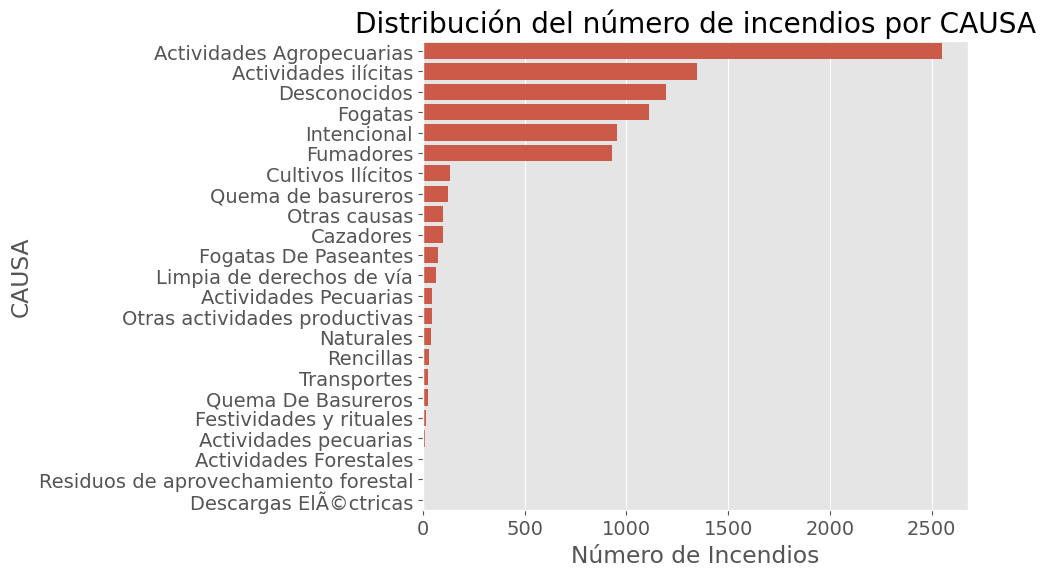

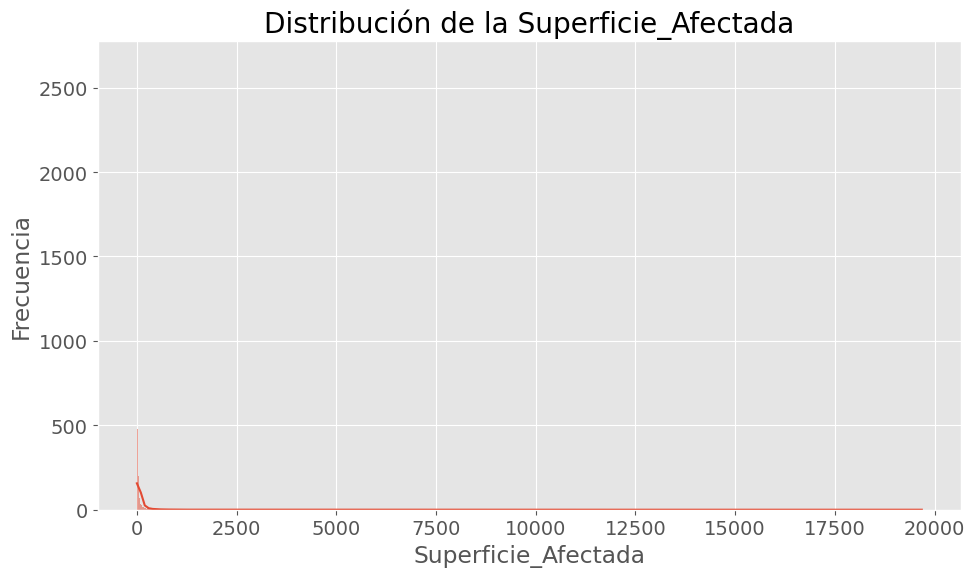

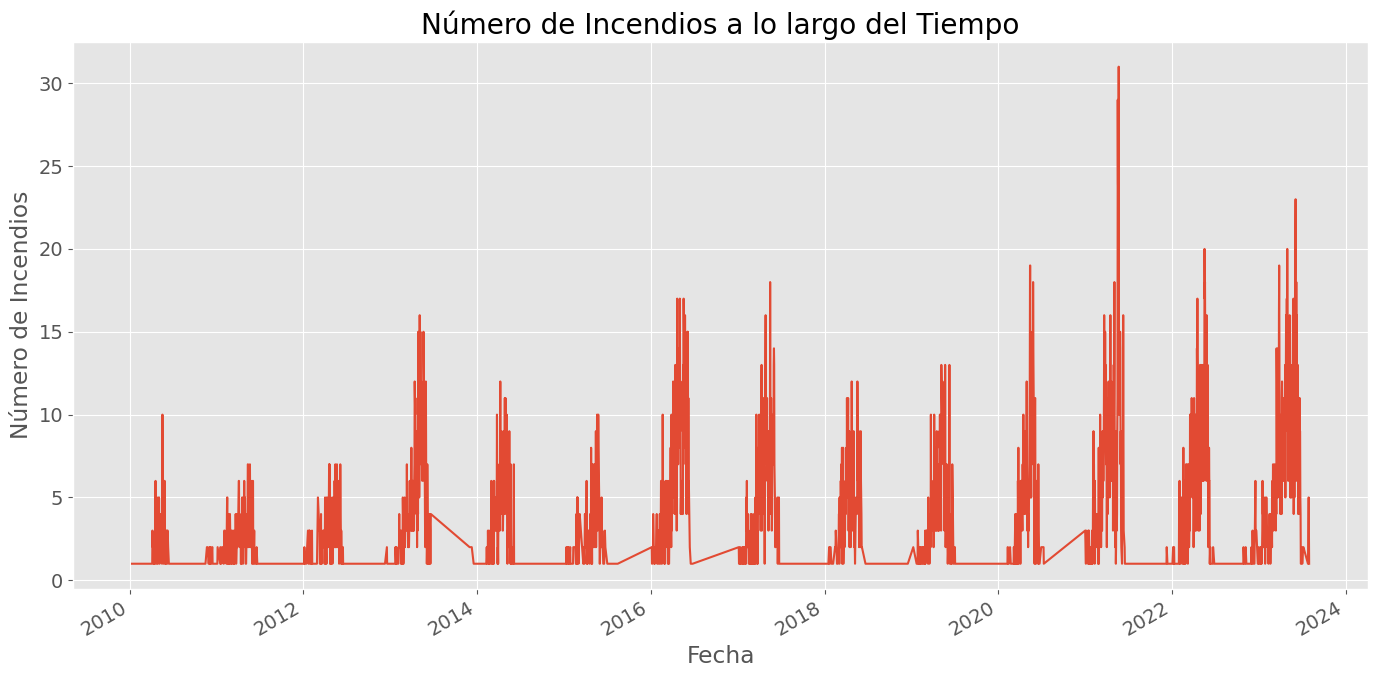

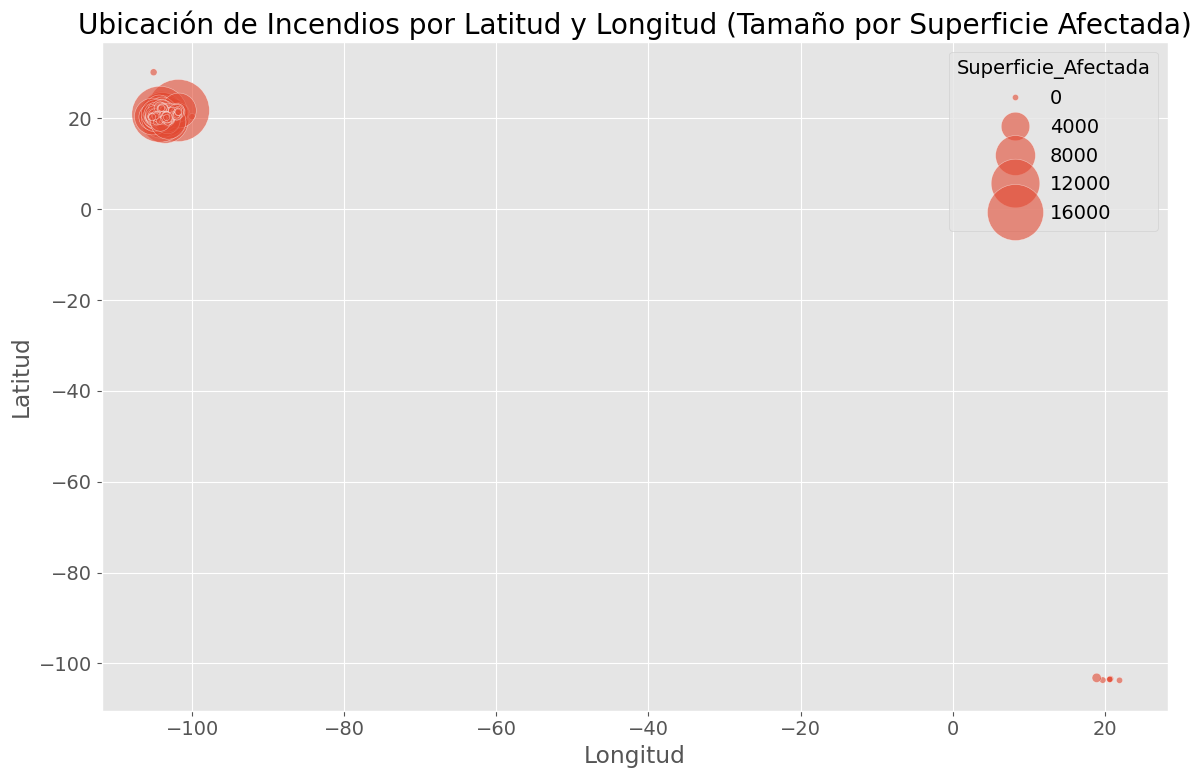


Coordenadas fuera de México (antes de corregir):
         LATITUD   LONGITUD FECHA_INIC
5094 -103.373611  20.763333 2020-01-07
5095 -103.707778  21.943056 2020-01-08
5096 -103.654722  19.738694 2020-01-14
5097 -103.493333  20.660611 2020-01-18
5098 -103.496333  20.661611 2020-01-19

Se encontraron 6 incendios fuera de los límites de México.

Intentando corregir coordenadas volteando LATITUD y LONGITUD...

Coordenadas fuera después de intentar corregir:
Todas las coordenadas corregidas ahora están dentro de los límites de México.


In [85]:
eda_incendios(df)

In [81]:
def plot_countplot(column):
    """Genera un gráfico de barras para una columna categórica"""
    if column in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=column, order=df[column].value_counts().index)
        plt.title(f'Distribución del número de incendios por {column}')
        plt.xlabel('Número de Incendios')
        plt.ylabel(column)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumna '{column}' no encontrada para análisis univariado.")

def plot_histogram(column):
    """Genera un histograma para una columna numérica"""
    if column in df.columns:
        df_positive = df[df[column] > 0].copy()  # Filtrar valores positivos
        if not df_positive.empty:
            plt.figure(figsize=(10, 6))
            sns.histplot(data=df_positive, x=column, kde=True)
            plt.title(f'Distribución de la {column}')
            plt.xlabel(column)
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nNo hay valores positivos en la columna '{column}' para graficar.")
    else:
        print(f"\nColumna '{column}' no encontrada para análisis univariado.")

def plot_time_series(date_column):
    """Genera un gráfico de serie temporal"""
    if date_column in df.columns and pd.api.types.is_datetime64_any_dtype(df[date_column]):
        incendios_por_fecha = df[date_column].value_counts().sort_index()

        plt.figure(figsize=(14, 7))
        incendios_por_fecha.plot()
        plt.title('Número de Incendios a lo largo del Tiempo')
        plt.xlabel('Fecha')
        plt.ylabel('Número de Incendios')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumna '{date_column}' no encontrada o no es de tipo datetime para análisis de serie de tiempo.")

def plot_scatter_map(lat_col, lon_col, size_column):
    """Genera un gráfico de dispersión con tamaño por superficie afectada"""
    if lat_col in df.columns and lon_col in df.columns and size_column in df.columns:
        df_scatter = df.dropna(subset=[lat_col, lon_col, size_column]).copy()

        if not df_scatter.empty:
            plt.figure(figsize=(12, 8))
            sns.scatterplot(data=df_scatter, x=lon_col, y=lat_col, size=size_column, alpha=0.6, sizes=(20, 2000))
            plt.title('Ubicación de Incendios por Latitud y Longitud (Tamaño por Superficie Afectada)')
            plt.xlabel('Longitud')
            plt.ylabel('Latitud')
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nNo hay datos válidos en {lat_col}, {lon_col} o {size_column} para el scatter plot.")
    else:
        print(f"\nColumnas '{lat_col}', '{lon_col}' o '{size_column}' no encontradas para el scatter plot.")


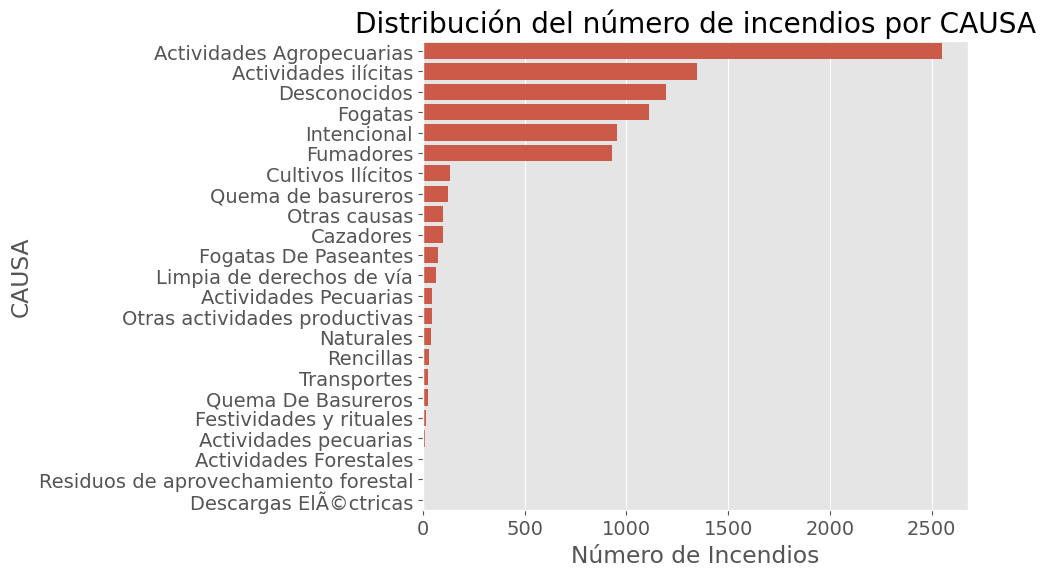

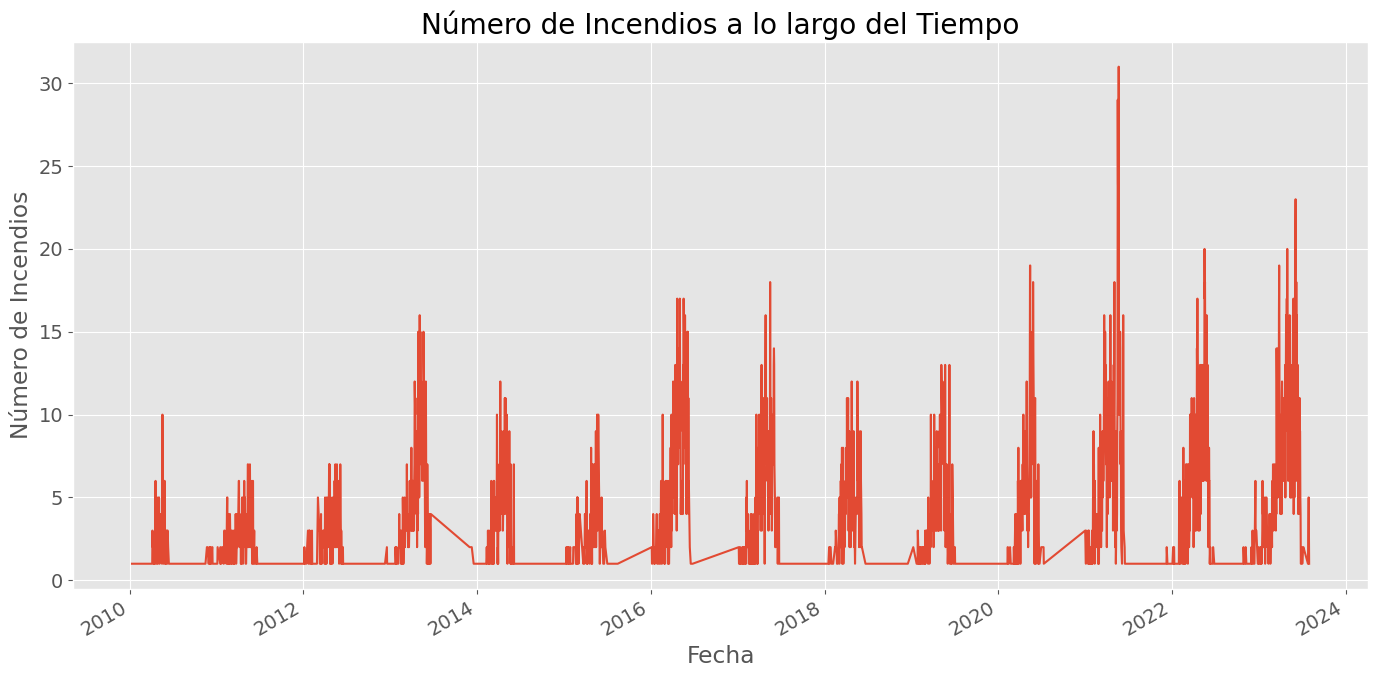

In [83]:
# Llamadas a funciones
plot_countplot('CAUSA')
plot_time_series('FECHA_INIC')
#plot_scatter_map('LATITUD', 'LONGITUD', 'Superficie_Afectada')
#plot_histogram('Superficie_Afectada')


--- Inicio del Análisis Exploratorio de Datos ---


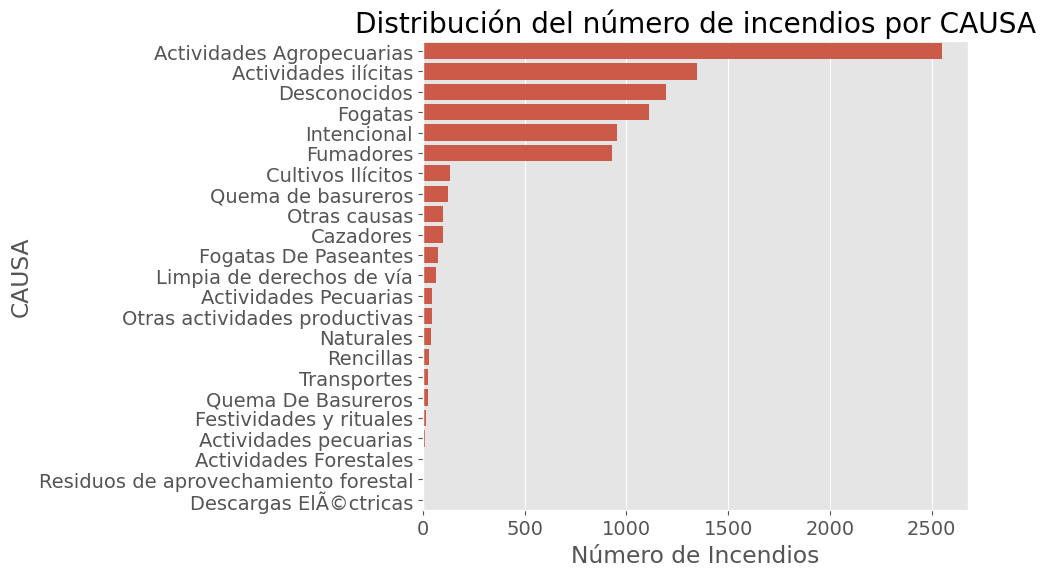

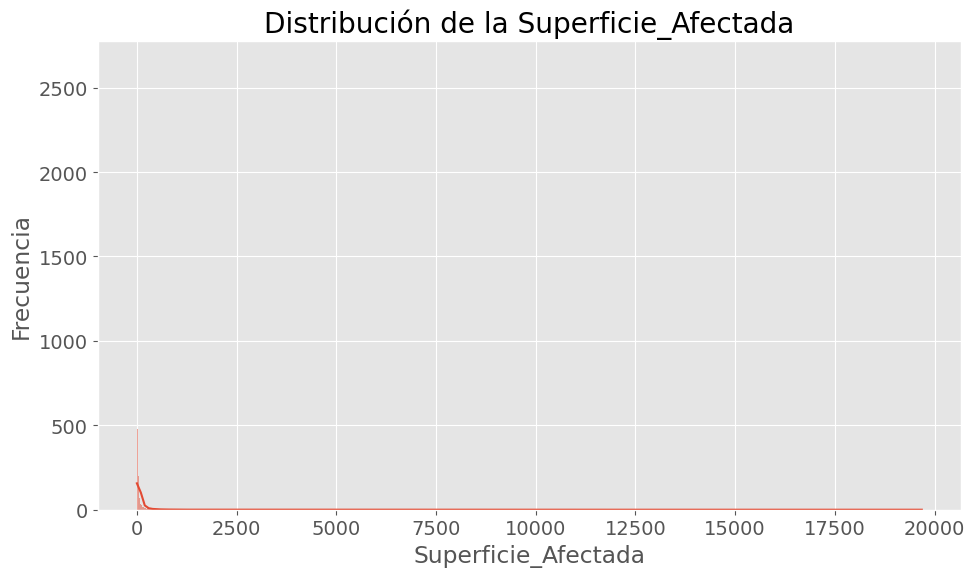

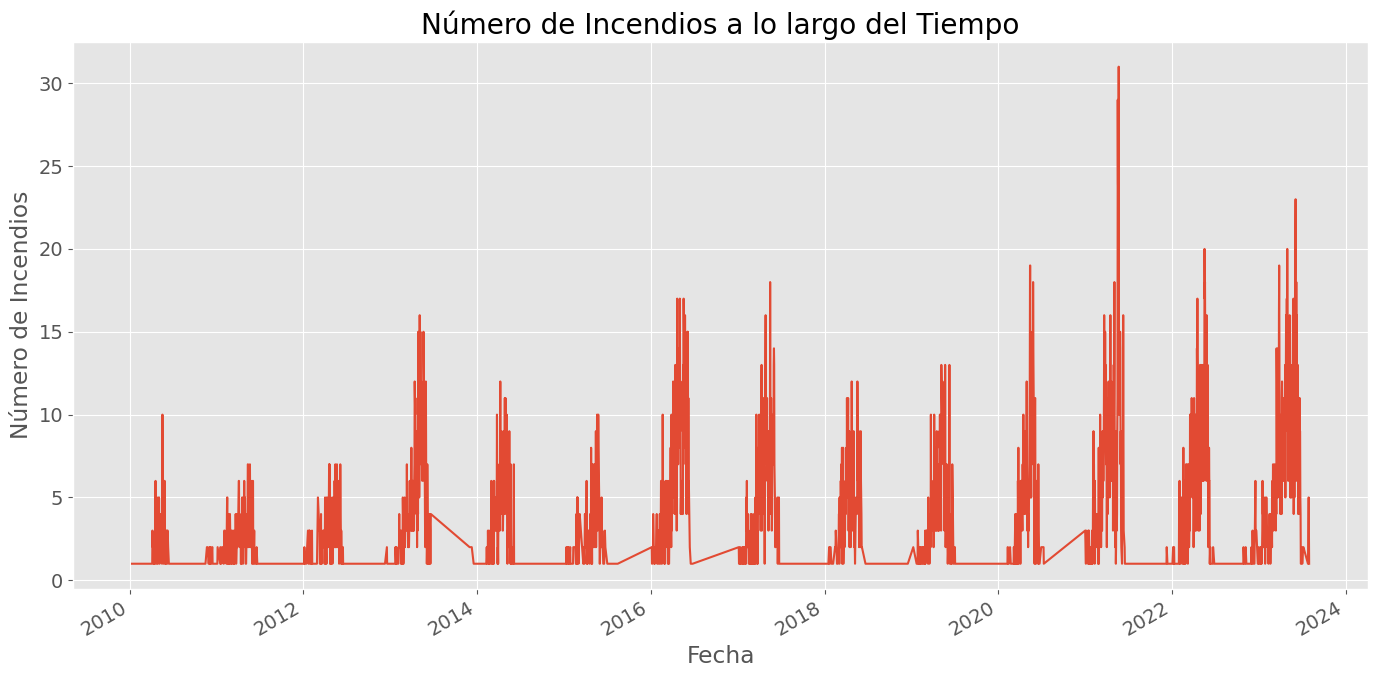

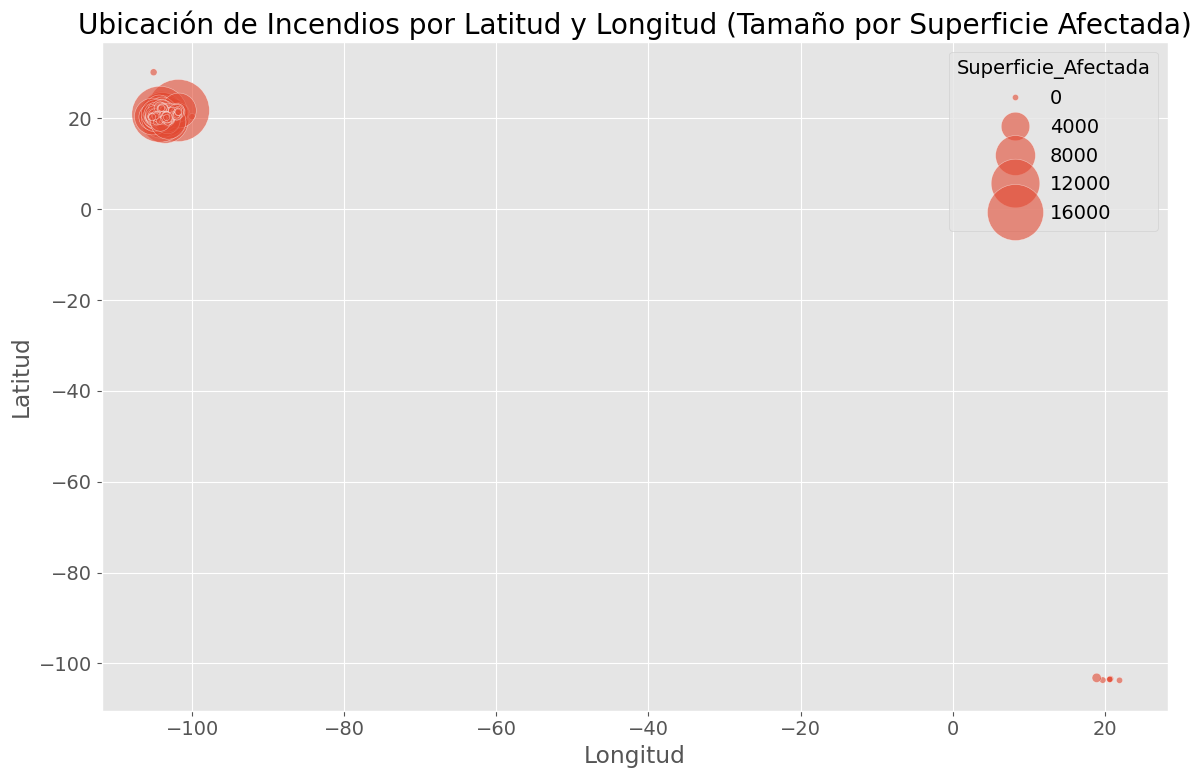


Coordenadas de incendios fuera de los límites aproximados de México (antes de corregir):
         LATITUD   LONGITUD FECHA_INIC
5094 -103.373611  20.763333 2020-01-07
5095 -103.707778  21.943056 2020-01-08
5096 -103.654722  19.738694 2020-01-14
5097 -103.493333  20.660611 2020-01-18
5098 -103.496333  20.661611 2020-01-19

Se encontraron 6 incendios fuera de los límites aproximados de México.

Intentando corregir coordenadas volteando LATITUD y LONGITUD...
Coordenadas para los incendios fuera de los límites aproximados de México han sido volteadas (LATITUD y LONGITUD intercambiadas) en el subset temporal.

Coordenadas que aún están fuera de los límites aproximados de México después de voltear:
Todas las coordenadas volteadas ahora se encuentran dentro de los límites aproximados de México.


### 5.6 Prueba Estadística de Asociación (Mes y Día)

Realizamos una prueba de Chi-cuadrado de independencia para evaluar si existe una asociación
estadísticamente significativa entre el mes y el día de inicio de los incendios.

In [65]:
def asociacion_mes_dia(df):
    output = widgets.Output()

    # Widgets para control
    mostrar_tabla_checkbox = widgets.Checkbox(value=False, description="Mostrar tabla completa")
    mostrar_esperadas_checkbox = widgets.Checkbox(value=False, description="Mostrar frecuencias esperadas")
    ejecutar_boton = widgets.Button(description="Ejecutar prueba", button_style='success')

    # Función a ejecutar al hacer clic
    def ejecutar_analisis(b):
        with output:
            clear_output()

            if df is not None and not df.empty:
                fecha_col = 'FECHA_INIC'

                if fecha_col in df.columns and pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
                    print("\n--- Prueba Estadística de Asociación (Mes y Día) ---")

                    df_valid = df.dropna(subset=[fecha_col]).copy()
                    if not df_valid.empty:
                        try:
                            df_valid['Mes'] = df_valid[fecha_col].dt.month
                            df_valid['Dia'] = df_valid[fecha_col].dt.day
                            print("✅ Columnas 'Mes' y 'Dia' extraídas correctamente.")

                            contingency_table = pd.crosstab(df_valid['Mes'], df_valid['Dia'])

                            if mostrar_tabla_checkbox.value:
                                print("\n📊 Tabla de Contingencia (Mes vs. Día):")
                                display(contingency_table)
                            else:
                                print("\n📊 Tabla de Contingencia (primeras filas):")
                                display(contingency_table.head())

                            chi2, p, dof, expected = chi2_contingency(contingency_table)

                            print("\n📈 Resultados de la Prueba de Chi-cuadrado:")
                            print(f"Chi²: {chi2:.4f} | Valor p: {p:.4f} | Grados de libertad: {dof}")

                            alpha = 0.05
                            print("\n📌 Interpretación:")
                            if p < alpha:
                                print(f"🔴 p < {alpha} → Rechazamos H₀. Existe asociación entre mes y día de inicio.")
                            else:
                                print(f"🟢 p ≥ {alpha} → No rechazamos H₀. No hay evidencia de asociación.")

                            if mostrar_esperadas_checkbox.value:
                                expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
                                print("\n📋 Frecuencias esperadas bajo H₀:")
                                display(expected_df)

                            print("\n📝 Nota: Esta prueba evalúa asociación, no causalidad.")
                        except Exception as e:
                            print(f"❌ Error en la prueba: {e}")
                    else:
                        print("⚠️ No hay fechas válidas para realizar la prueba.")
                else:
                    print(f"⚠️ La columna '{fecha_col}' no existe o no es datetime.")
            else:
                print("⚠️ El DataFrame está vacío o no fue cargado.")

    ejecutar_boton.on_click(ejecutar_analisis)

    # Mostrar interfaz
    display(widgets.VBox([
        widgets.HTML("<h4>Asociación entre Mes y Día de Inicio de Incendios</h4>"),
        mostrar_tabla_checkbox,
        mostrar_esperadas_checkbox,
        ejecutar_boton,
        output
    ]))

In [68]:
asociacion_mes_dia(df)

### 5.7 Visualización de Calendario de Calor

Creamos un calendario de calor para visualizar la frecuencia diaria de los incendios
a lo largo del tiempo, utilizando la columna 'FECHA_INIC'.

In [69]:
def heatmap_calendario_interactivo(df):
    output = widgets.Output()
    fecha_col = 'FECHA_INIC'

    # Validaciones iniciales
    if df is None or df.empty:
        print("⚠️ El DataFrame está vacío o no se pudo cargar.")
        return
    if fecha_col not in df.columns:
        print(f"⚠️ La columna '{fecha_col}' no se encuentra en el DataFrame.")
        return
    if not pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
        print(f"⚠️ La columna '{fecha_col}' no es de tipo datetime.")
        return

    df_valid = df.dropna(subset=[fecha_col]).copy()
    df_valid['Fecha'] = df_valid[fecha_col].dt.date

    if df_valid.empty:
        print("⚠️ No hay fechas válidas para graficar.")
        return

    # Conteo diario
    daily_counts = df_valid['Fecha'].value_counts().sort_index()
    daily_counts.index = pd.to_datetime(daily_counts.index)

    if daily_counts.empty:
        print("⚠️ No hay datos de incendios para generar el calendario de calor.")
        return

    # Años disponibles
    años_disponibles = sorted(daily_counts.index.year.unique())

    # Widgets interactivos
    año_selector = widgets.Dropdown(
        options=años_disponibles,
        description='Año:',
        value=años_disponibles[0]
    )

    cmap_selector = widgets.Dropdown(
        options=['Oranges', 'YlOrRd', 'Reds', 'Greens', 'Blues', 'PuRd', 'BuPu', 'GnBu'],
        description='Colormap:',
        value='Oranges'
    )

    boton = widgets.Button(description='Generar Heatmap', button_style='success')

    def graficar(b):
        with output:
            clear_output()
            try:
                año = año_selector.value
                cmap = cmap_selector.value

                serie_anual = daily_counts[daily_counts.index.year == año]

                if serie_anual.empty:
                    print(f"⚠️ No hay datos para el año {año}.")
                    return

                fig, ax = plt.subplots(figsize=(22, 10))
                calmap.yearplot(
                    serie_anual,
                    year=año,
                    ax=ax,
                    cmap=cmap,
                    fillcolor='whitesmoke',
                    linewidth=1,
                    daylabels='MTWTFSS',
                    dayticks=[0, 1, 2, 3, 4, 5, 6],
                    monthlabels='Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec'.split(),
                    monthticks=True
                )

                # Título
                fig.suptitle(f'📆 Calendario de Incendios por Día - {año}', fontsize=22, fontweight='bold', y=0.65)

                # Colorbar
                norm = mpl.colors.Normalize(vmin=serie_anual.min(), vmax=serie_anual.max())
                sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.03)
                cbar.set_label('🔥 Número de Incendios por Día', fontsize=12)

                plt.tight_layout(rect=[0, 0.03, 1, 0.93])
                plt.show()
            except Exception as e:
                print(f"❌ Error al generar el heatmap: {e}")

    boton.on_click(graficar)

    # Mostrar interfaz
    display(widgets.VBox([
        widgets.HTML("<h4>🔥 Calendario de Incendios Forestales por Día</h4>"),
        año_selector,
        cmap_selector,
        boton,
        output
    ]))

In [70]:
heatmap_calendario_interactivo(df)

### 5.8 Análisis por Causa, Vegetación y Municipio

Exploramos la frecuencia y el área afectada por diferentes causas de incendio,
tipos de vegetación y municipios. También analizamos el tamaño medio de los
incendios por causa.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Variables base ---
causa_col = 'CAUSA'
veg_col = 'Tipo de Vegteacion'
municipio_col = 'MUNICIPIO'
superficie_col = 'Superficie_Afectada'

# --- Validación del DataFrame ---
def validate_df(df, cols):
    return df is not None and not df.empty and all(col in df.columns for col in cols)

# --- Función principal de análisis interactivo ---
def interactive_analysis(df):

    # Widgets
    analysis_type = widgets.ToggleButtons(
        options=['Causa', 'Vegetación', 'Municipio'],
        description='Análisis:',
        style={'description_width': 'initial'}
    )

    chart_type = widgets.Dropdown(
        options=['Barras', 'Treemap', 'Boxplot'],
        value='Barras',
        description='Tipo de Gráfico:'
    )

    color_picker = widgets.ColorPicker(
        value='#1f77b4',
        description='Color:'
    )

    top_n_slider = widgets.IntSlider(
        value=10,
        min=5,
        max=30,
        step=1,
        description='Top N:',
        continuous_update=False
    )

    # Función de actualización dinámica
    def update_plot(analysis, chart, color, top_n):
        clear_output(wait=True)
        display(ui)

        if not validate_df(df, [causa_col, veg_col, municipio_col, superficie_col]):
            print("❌ DataFrame inválido o columnas faltantes.")
            return

        col_map = {
            'Causa': causa_col,
            'Vegetación': veg_col,
            'Municipio': municipio_col
        }

        group_col = col_map[analysis]
        df_clean = df.dropna(subset=[group_col, superficie_col]).copy()
        df_clean[superficie_col] = pd.to_numeric(df_clean[superficie_col], errors='coerce')
        df_clean = df_clean.dropna(subset=[superficie_col])

        freq_counts = df[group_col].value_counts().nlargest(top_n)
        surface_sums = df_clean.groupby(group_col)[superficie_col].sum().sort_values(ascending=False).head(top_n)

        if chart == 'Barras':
            plt.figure(figsize=(10, 6))
            sns.countplot(data=df[df[group_col].isin(freq_counts.index)],
                          y=group_col,
                          order=freq_counts.index,
                          color=color)
            plt.title(f'Frecuencia de Incendios por {analysis}')
            plt.xlabel('Número de Incendios')
            plt.ylabel(analysis)
            plt.tight_layout()
            plt.show()

            plt.figure(figsize=(10, 6))
            surface_sums.plot(kind='barh', color=color)
            plt.title(f'Área Total Afectada por {analysis}')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(analysis)
            plt.tight_layout()
            plt.show()

        elif chart == 'Treemap':
            if surface_sums.empty:
                print("No hay suficientes datos para generar un treemap.")
                return
            sizes = surface_sums.tolist()
            labels = [f"{label}\n{size:.1f} Ha" for label, size in zip(surface_sums.index, sizes)]
            plt.figure(figsize=(12, 8))
            squarify.plot(sizes=sizes, label=labels, alpha=.8, color=[color]*len(sizes), text_kwargs={'fontsize': 8})
            plt.title(f'Treemap de Área Afectada por {analysis}')
            plt.axis('off')
            plt.show()

        elif chart == 'Boxplot':
            plt.figure(figsize=(10, 6))
            sns.boxplot(data=df_clean[df_clean[group_col].isin(freq_counts.index)],
                        x=superficie_col,
                        y=group_col,
                        palette=[color])
            plt.title(f'Distribución del Tamaño de Incendios por {analysis}')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(analysis)
            plt.tight_layout()
            plt.show()

    # Interactividad
    ui = widgets.VBox([analysis_type, chart_type, top_n_slider, color_picker])
    out = widgets.interactive_output(update_plot, {
        'analysis': analysis_type,
        'chart': chart_type,
        'color': color_picker,
        'top_n': top_n_slider
    })

    display(ui, out)


In [71]:
interactive_analysis(df)

Output()

## 6. Análisis Geoespacial

Convertimos los datos a un GeoDataFrame para realizar análisis y visualizaciones geoespaciales.
Intentamos cargar un shapefile (ej. de Jalisco) para usarlo como capa base en el mapa.

**Nota:** Necesitas tener el archivo shapefile de Jalisco (ej. 'Jalisco.shp')
y sus archivos asociados (.shx, .dbf, .prj, etc.) en la ruta especificada.


In [ ]:
df.unique()

In [39]:
#unique de la columna Tipo de Vegteacion

if df is not None and not df.empty:
    print(df['Tipo de Vegteacion'].unique())


['Bosque De Encino' 'Bosque Templado Frío' 'Bosque de Pino Encino'
 'Pastizal Natural' 'Pastizal Inducido' 'Selva Baja Caducifolia'
 'Bosque de Encino' 'Matorral de Coníferas' 'Bosque de Pino'
 'Matorral Submontano ' 'Palmar Natural' 'Palmar Inducido'
 ' Bosque de coníferas' 'Selva Mediana Subcaducifolia' 'Bosque Mesofilo'
 'Bosque de Oyamel' 'Chaparral' 'Pastizal Gypsáfilo' 'Bosque de Cedro '
 'Matorral Sarcocaule' 'Pastizal Halófilo' 'Bosque Inducido' nan
 'Selva Tropical' 'Matorral Subtropical ' 'Mezquital'
 'Matorral Desertico Microfilo' 'Bosque de Tascate' 'Bosque de Galería'
 'Selva Baja Perennifolia' 'Bosque Cultivado' 'Matorral Crasicaule']


Dropdown(description='Estado:', options=('Jalisco',), value='Jalisco')

Dropdown(description='Año:', index=11, options=('Todos', 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,…

Dropdown(description='Vegetación:', index=1, options=('Todas las vegetaciones', 'Bosques combinados', ' Bosque…

FloatSlider(value=0.01, continuous_update=False, description='Tamaño:', max=0.1, min=0.001, readout_format='.3…

Button(description='Mostrar Mapa', style=ButtonStyle())


--- Análisis Geoespacial para el estado de Jalisco ---
➡️ Se encontraron 253 incendios con los criterios seleccionados.
🔥 Se encontraron 253 incendios dentro del estado de Jalisco tras la unión espacial.


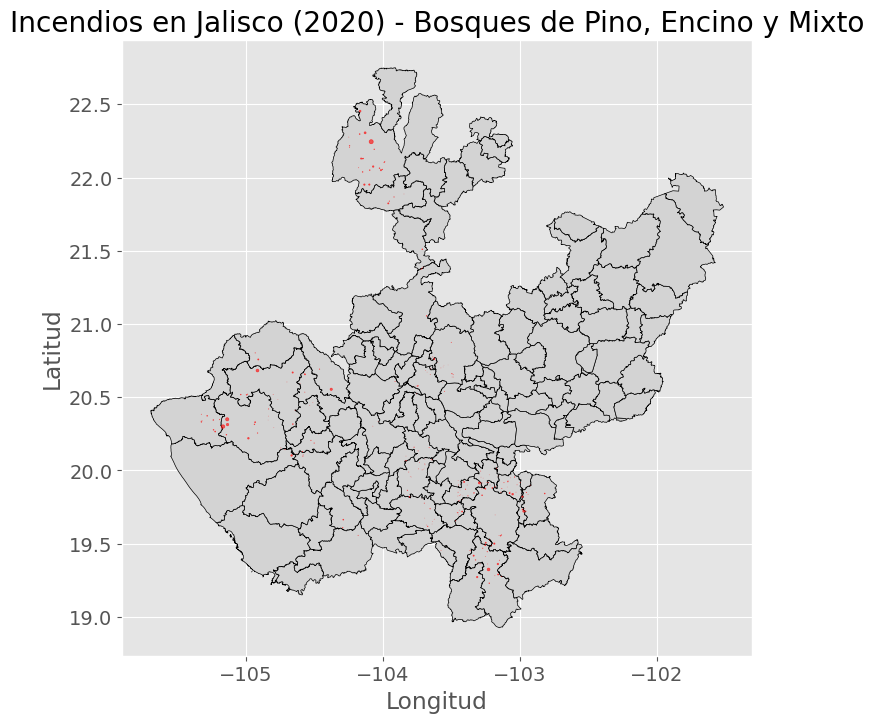

In [74]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --------------------------
# FUNCION PRINCIPAL
# --------------------------
def analizar_incendios_en_estado(df, estado, anio, tipo_vegetacion, marker_scale=0.01):
    if df is None or df.empty:
        print("\n⚠️ El DataFrame está vacío o no fue cargado correctamente.")
        return

    print(f"\n--- Análisis Geoespacial para el estado de {estado} ---")

    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'

    if tipo_vegetacion == "Bosques combinados":
        tipos = ["Bosque de Pino Encino", "Bosque de Pino", "Bosque de Encino"]
        filtros = (df['ENTIDAD'] == estado) & (df['Tipo de Vegteacion'].isin(tipos))
    elif tipo_vegetacion == "Todas las vegetaciones":
        filtros = (df['ENTIDAD'] == estado)
    else:
        filtros = (df['ENTIDAD'] == estado) & (df['Tipo de Vegteacion'] == tipo_vegetacion)

    # Filtrar por año si es distinto de 'Todos'
    if anio != 'Todos':
        filtros = filtros & (df['AÑO'] == anio)

    df_filtrado = df.loc[filtros].copy()

    if df_filtrado.empty:
        print("⚠️ No se encontraron incendios con los criterios seleccionados.")
        return

    print(f"➡️ Se encontraron {len(df_filtrado)} incendios con los criterios seleccionados.")

    # Limpiar coordenadas
    df_filtrado[lat_col] = pd.to_numeric(df_filtrado[lat_col], errors='coerce')
    df_filtrado[lon_col] = pd.to_numeric(df_filtrado[lon_col], errors='coerce')
    df_filtrado.dropna(subset=[lat_col, lon_col], inplace=True)

    # Corregir coordenadas fuera de México
    min_lat, max_lat = 14.5, 32.7
    min_lon, max_lon = -118.5, -86.7
    mask_fuera = (
        (df_filtrado[lat_col] < min_lat) | (df_filtrado[lat_col] > max_lat) |
        (df_filtrado[lon_col] < min_lon) | (df_filtrado[lon_col] > max_lon)
    )
    df_filtrado.loc[mask_fuera, [lat_col, lon_col]] = df_filtrado.loc[mask_fuera, [lon_col, lat_col]].values

    # Crear GeoDataFrame
    try:
        gdf = gpd.GeoDataFrame(df_filtrado, geometry=gpd.points_from_xy(df_filtrado[lon_col], df_filtrado[lat_col]), crs="EPSG:4326")
    except Exception as e:
        print(f"❌ Error creando GeoDataFrame: {e}")
        return

    # Leer shapefile
    shapefile_path = '/content/mun22gw.shp'
    try:
        municipios = gpd.read_file(shapefile_path)
        estado_gdf = municipios[municipios['NOM_ENT'] == estado]
        if estado_gdf.empty:
            print(f"⚠️ No se encontró el estado '{estado}' en el shapefile.")
            return

        if estado_gdf.crs != gdf.crs:
            estado_gdf = estado_gdf.to_crs(gdf.crs)

        resultado = gpd.sjoin(gdf, estado_gdf, how='inner', predicate='intersects')
        print(f"🔥 Se encontraron {len(resultado)} incendios dentro del estado de {estado} tras la unión espacial.")

        # Visualización
        fig, ax = plt.subplots(figsize=(12, 8))
        estado_gdf.plot(ax=ax, color='lightgray', edgecolor='black')
        resultado.plot(
            ax=ax,
            marker='o',
            color='red',
            alpha=0.6,
            markersize=resultado['TOTAL_HA'] * marker_scale
        )

        if tipo_vegetacion == "Todas las vegetaciones":
            titulo = "Todos los tipos de vegetación"
        elif tipo_vegetacion == "Bosques combinados":
            titulo = "Bosques de Pino, Encino y Mixto"
        else:
            titulo = tipo_vegetacion

        ax.set_title(f"Incendios en {estado} ({anio}) - {titulo}")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"❌ Error al procesar shapefile o unir datos: {e}")

# --------------------------
# WIDGETS INTERACTIVOS
# --------------------------

# Opciones de vegetación
vegetation_options = sorted(df['Tipo de Vegteacion'].dropna().unique().tolist())
vegetation_options.insert(0, "Bosques combinados")
vegetation_options.insert(0, "Todas las vegetaciones")

# Estado
estado_dropdown = widgets.Dropdown(
    options=sorted(df['ENTIDAD'].unique()),
    value='Jalisco',
    description='Estado:'
)

# Año (con opción 'Todos')
years = sorted(df['AÑO'].dropna().unique().tolist())
year_dropdown = widgets.Dropdown(
    options=['Todos'] + years,
    value=2020,
    description='Año:'
)

# Tipo de vegetación
vegetation_dropdown = widgets.Dropdown(
    options=vegetation_options,
    value='Bosques combinados',
    description='Vegetación:'
)

# Escala de tamaño del marcador
marker_slider = widgets.FloatSlider(
    value=0.01,
    min=0.001,
    max=0.1,
    step=0.001,
    description='Tamaño:',
    continuous_update=False,
    readout_format='.3f'
)

# Botón y función de interacción
button = widgets.Button(description="Mostrar Mapa")

def on_button_clicked(b):
    clear_output(wait=True)
    display(estado_dropdown, year_dropdown, vegetation_dropdown, marker_slider, button)
    analizar_incendios_en_estado(
        df,
        estado=estado_dropdown.value,
        anio=year_dropdown.value,
        tipo_vegetacion=vegetation_dropdown.value,
        marker_scale=marker_slider.value
    )

button.on_click(on_button_clicked)

# Mostrar interfaz y graficar inicialmente
display(estado_dropdown, year_dropdown, vegetation_dropdown, marker_slider, button)
on_button_clicked(None)


## 7. Conclusiones y Próximos Pasos

Aquí puedes escribir tus observaciones clave basadas en el análisis y las visualizaciones.
Sugiere posibles próximos pasos, como análisis más profundos, modelado predictivo, etc.

In [ ]:
if df is not None and not df.empty:
    print("\n--- Análisis Completo ---")
    print("Hemos realizado la carga, limpieza básica, inspección y algunos análisis exploratorios.")
    print("Revisa las visualizaciones y estadísticas generadas para obtener insights sobre los datos de incendios.")
else:
     print("\nEl análisis no pudo completarse debido a errores en la carga o procesamiento de datos.")

"""
**Ejemplos de Conclusiones:**
- Se observan tendencias temporales en el número de incendios.
- Ciertas causas son más frecuentes que otras.
- La distribución espacial de los incendios muestra concentración en áreas específicas.

**Posibles Próximos Pasos:**
- Realizar análisis de correlación entre variables.
- Investigar la relación entre los incendios y factores ambientales o socioeconómicos.
- Desarrollar modelos para predecir la ocurrencia o el tamaño de los incendios.
- Mejorar la limpieza de datos para manejar otros tipos de inconsistencias.
- Explorar visualizaciones interactivas.
"""




--- Análisis Completo ---
Hemos realizado la carga, limpieza básica, inspección y algunos análisis exploratorios.
Revisa las visualizaciones y estadísticas generadas para obtener insights sobre los datos de incendios.


'\n**Ejemplos de Conclusiones:**\n- Se observan tendencias temporales en el número de incendios.\n- Ciertas causas son más frecuentes que otras.\n- La distribución espacial de los incendios muestra concentración en áreas específicas.\n\n**Posibles Próximos Pasos:**\n- Realizar análisis de correlación entre variables.\n- Investigar la relación entre los incendios y factores ambientales o socioeconómicos.\n- Desarrollar modelos para predecir la ocurrencia o el tamaño de los incendios.\n- Mejorar la limpieza de datos para manejar otros tipos de inconsistencias.\n- Explorar visualizaciones interactivas.\n'

----------------------------
----------------------------

NO UTILICE



```
if df is not None and not df.empty:
    print("\n--- Inicio del Análisis Exploratorio de Datos ---")

    # Análisis Univariado - Ejemplo: Distribución de una columna categórica (ej. 'CAUSA')
    # Usando la columna 'CAUSA'
    causa_col = 'CAUSA'
    if causa_col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=causa_col, order=df[causa_col].value_counts().index)
        plt.title(f'Distribución del número de incendios por {causa_col}')
        plt.xlabel('Número de Incendios')
        plt.ylabel(causa_col)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumna '{causa_col}' no encontrada para análisis univariado.")


    # Análisis Univariado - Ejemplo: Distribución de una columna numérica (ej. 'Superficie_Afectada')
    # Usando la columna 'Superficie_Afectada' (derivada de 'TOTAL_HA')
    superficie_col = 'Superficie_Afectada'
    if superficie_col in df.columns:
         # Eliminar valores no positivos o atípicos si es necesario antes de visualizar
        df_superficie_positiva = df[df[superficie_col] > 0].copy()
        if not df_superficie_positiva.empty:
            plt.figure(figsize=(10, 6))
            sns.histplot(data=df_superficie_positiva, x=superficie_col, kde=True)
            plt.title(f'Distribución de la {superficie_col}')
            plt.xlabel(superficie_col)
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            plt.show()
        else:
             print(f"\nNo hay valores positivos en la columna '{superficie_col}' para graficar.")
    else:
        print(f"\nColumna '{superficie_col}' no encontrada para análisis univariado.")


    # Análisis Bivariado - Ejemplo: Relación entre Fecha y número de incendios (Serie de Tiempo)
    # Usando la columna 'FECHA_INIC'
    fecha_col = 'FECHA_INIC'
    if fecha_col in df.columns and pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
        # Agrupar por fecha y contar incendios
        incendios_por_fecha = df[fecha_col].value_counts().sort_index()

        plt.figure(figsize=(14, 7))
        incendios_por_fecha.plot()
        plt.title('Número de Incendios a lo largo del Tiempo')
        plt.xlabel('Fecha')
        plt.ylabel('Número de Incendios')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumna '{fecha_col}' no encontrada o no es de tipo datetime para análisis de serie de tiempo.")

    # Análisis Bivariado - Ejemplo: Relación entre Latitud, Longitud y Superficie Afectada (Scatter Plot)
    # Usando las columnas 'LATITUD', 'LONGITUD' y 'Superficie_Afectada'
    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'
    superficie_col = 'Superficie_Afectada'

    if lat_col in df.columns and lon_col in df.columns and superficie_col in df.columns:
        # Eliminar filas con valores no válidos en las columnas usadas para el scatter plot
        df_scatter = df.dropna(subset=[lat_col, lon_col, superficie_col]).copy()
        # Opcional: Filtrar por superficie afectada para evitar outliers extremos en la visualización
        # df_scatter = df_scatter[df_scatter[superficie_col] < df_scatter[superficie_col].quantile(0.95)] # Ejemplo: filtrar el 5% superior

        if not df_scatter.empty:
            plt.figure(figsize=(12, 8))
            # Usamos log scale para el tamaño si la superficie varía mucho
            sns.scatterplot(data=df_scatter, x=lon_col, y=lat_col, size=superficie_col, alpha=0.6, sizes=(20, 2000))
            plt.title('Ubicación de Incendios por Latitud y Longitud (Tamaño por Superficie Afectada)')
            plt.xlabel('Longitud')
            plt.ylabel('Latitud')
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nNo hay datos válidos en {lat_col}, {lon_col} o {superficie_col} para el scatter plot.")
    else:
         print(f"\nColumnas '{lat_col}', '{lon_col}' o '{superficie_col}' no encontradas para el scatter plot.")

    # %% [markdown]

    """
    ### 5.5 Verificación y Corrección de Coordenadas Fuera de México

    Identificamos incendios cuyas coordenadas caen fuera de los límites geográficos
    aproximados de México y, opcionalmente, intentamos corregir un posible error
    común de intercambio de latitud y longitud.
    """

    # Identificar y opcionalmente corregir coordenadas fuera de México
    # Definir límites aproximados de México (pueden necesitar ajuste según la precisión requerida)
    min_lat, max_lat = 14.5, 32.7 # Latitud aproximada de México
    min_lon, max_lon = -118.5, -86.7 # Longitud aproximada de México (Oeste es negativo)

    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'

    if lat_col in df.columns and lon_col in df.columns:
         # Asegurarse de que las columnas de coordenadas sean numéricas y no nulas antes de filtrar
        df_coords_mexico = df.dropna(subset=[lat_col, lon_col]).copy()
        df_coords_mexico[lat_col] = pd.to_numeric(df_coords_mexico[lat_col], errors='coerce')
        df_coords_mexico[lon_col] = pd.to_numeric(df_coords_mexico[lon_col], errors='coerce')
        df_coords_mexico.dropna(subset=[lat_col, lon_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_coords_mexico.empty:
            # Crear una máscara booleana para identificar filas fuera de los límites
            outside_mexico_mask = (df_coords_mexico[lat_col] < min_lat) | (df_coords_mexico[lat_col] > max_lat) | \
                                  (df_coords_mexico[lon_col] < min_lon) | (df_coords_mexico[lon_col] > max_lon)

            # DataFrame con las coordenadas fuera de los límites
            outside_mexico_df = df_coords_mexico[outside_mexico_mask].copy() # Usar .copy() para evitar SettingWithCopyWarning

            print("\nCoordenadas de incendios fuera de los límites aproximados de México (antes de corregir):")
            if not outside_mexico_df.empty:
                # Mostrar las primeras filas del DataFrame filtrado con las columnas relevantes
                print(outside_mexico_df[[lat_col, lon_col, fecha_col]].head()) # Usando la columna de fecha definida antes
                print(f"\nSe encontraron {len(outside_mexico_df)} incendios fuera de los límites aproximados de México.")

                # Paso 11.1: Voltear las coordenadas (intercambiar LATITUD y LONGITUD) para las filas fuera de México
                # Esto asume que el error es un simple intercambio de latitud y longitud
                # Solo se aplica a las filas identificadas por la máscara
                # Es crucial aplicar esto al DataFrame original 'df' si quieres que el cambio persista
                # Pero para este análisis, lo aplicaremos solo al subset filtrado para no modificar el df original aquí
                # Si deseas modificar el df original, mueve este bloque a la sección de Limpieza (Paso 4)
                print("\nIntentando corregir coordenadas volteando LATITUD y LONGITUD...")

                # Crear copias temporales para el intercambio en las filas identificadas
                original_lat_subset = df_coords_mexico.loc[outside_mexico_mask, lat_col].copy()
                original_lon_subset = df_coords_mexico.loc[outside_mexico_mask, lon_col].copy()

                # Realizar el intercambio en el subset
                df_coords_mexico.loc[outside_mexico_mask, lat_col] = original_lon_subset
                df_coords_mexico.loc[outside_mexico_mask, lon_col] = original_lat_subset

                print("Coordenadas para los incendios fuera de los límites aproximados de México han sido volteadas (LATITUD y LONGITUD intercambiadas) en el subset temporal.")

                # Opcional: Verificar si las coordenadas volteadas ahora están dentro de los límites
                # Crear una máscara para las coordenadas que *aún* están fuera después de voltear en el subset
                still_outside_mask_after_flip = (df_coords_mexico[lat_col] < min_lat) | (df_coords_mexico[lat_col] > max_lat) | \
                                                (df_coords_mexico[lon_col] < min_lon) | (df_coords_mexico[lon_col] > max_lon)

                still_outside_df_after_flip = df_coords_mexico[still_outside_mask_after_flip]

                print("\nCoordenadas que aún están fuera de los límites aproximados de México después de voltear:")
                if not still_outside_df_after_flip.empty:
                    print(still_outside_df_after_flip[[lat_col, lon_col, fecha_col]].head()) # Usando la columna de fecha definida antes
                    print(f"\nSe encontraron {len(still_outside_df_after_flip)} incendios que aún están fuera después de voltear las coordenadas.")
                    print("Considera revisar estas coordenadas manualmente o refinar los límites de México.")
                else:
                    print("Todas las coordenadas volteadas ahora se encuentran dentro de los límites aproximados de México.")

            else:
                print("No se encontraron incendios fuera de los límites aproximados de México en este conjunto de datos.")
        else:
            print("\nNo hay datos de coordenadas válidos para verificar la ubicación fuera de México.")
    else:
        print(f"\nColumnas '{lat_col}' o '{lon_col}' no encontradas para verificar la ubicación fuera de México.")


else:
    print("\nNo se pudo cargar o el DataFrame está vacío. No se realizará el Análisis Exploratorio de Datos.")
```





```
if df is not None and not df.empty:
    print("\n--- Inicio del Análisis Exploratorio de Datos ---")

    # Análisis Univariado - Ejemplo: Distribución de una columna categórica (ej. 'CAUSA')
    # Usando la columna 'CAUSA'
    causa_col = 'CAUSA'
    if causa_col in df.columns:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=causa_col, order=df[causa_col].value_counts().index)
        plt.title(f'Distribución del número de incendios por {causa_col}')
        plt.xlabel('Número de Incendios')
        plt.ylabel(causa_col)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumna '{causa_col}' no encontrada para análisis univariado.")


    # Análisis Univariado - Ejemplo: Distribución de una columna numérica (ej. 'Superficie_Afectada')
    # Usando la columna 'Superficie_Afectada' (derivada de 'TOTAL_HA')
    superficie_col = 'Superficie_Afectada'
    if superficie_col in df.columns:
         # Eliminar valores no positivos o atípicos si es necesario antes de visualizar
        df_superficie_positiva = df[df[superficie_col] > 0].copy()
        if not df_superficie_positiva.empty:
            plt.figure(figsize=(10, 6))
            sns.histplot(data=df_superficie_positiva, x=superficie_col, kde=True)
            plt.title(f'Distribución de la {superficie_col}')
            plt.xlabel(superficie_col)
            plt.ylabel('Frecuencia')
            plt.tight_layout()
            plt.show()
        else:
             print(f"\nNo hay valores positivos en la columna '{superficie_col}' para graficar.")
    else:
        print(f"\nColumna '{superficie_col}' no encontrada para análisis univariado.")


    # Análisis Bivariado - Ejemplo: Relación entre Fecha y número de incendios (Serie de Tiempo)
    # Usando la columna 'FECHA_INIC'
    fecha_col = 'FECHA_INIC'
    if fecha_col in df.columns and pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
        # Agrupar por fecha y contar incendios
        incendios_por_fecha = df[fecha_col].value_counts().sort_index()

        plt.figure(figsize=(14, 7))
        incendios_por_fecha.plot()
        plt.title('Número de Incendios a lo largo del Tiempo')
        plt.xlabel('Fecha')
        plt.ylabel('Número de Incendios')
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nColumna '{fecha_col}' no encontrada o no es de tipo datetime para análisis de serie de tiempo.")

    # Análisis Bivariado - Ejemplo: Relación entre Latitud, Longitud y Superficie Afectada (Scatter Plot)
    # Usando las columnas 'LATITUD', 'LONGITUD' y 'Superficie_Afectada'
    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'
    superficie_col = 'Superficie_Afectada'

    if lat_col in df.columns and lon_col in df.columns and superficie_col in df.columns:
        # Eliminar filas con valores no válidos en las columnas usadas para el scatter plot
        df_scatter = df.dropna(subset=[lat_col, lon_col, superficie_col]).copy()
        # Opcional: Filtrar por superficie afectada para evitar outliers extremos en la visualización
        # df_scatter = df_scatter[df_scatter[superficie_col] < df_scatter[superficie_col].quantile(0.95)] # Ejemplo: filtrar el 5% superior

        if not df_scatter.empty:
            plt.figure(figsize=(12, 8))
            # Usamos log scale para el tamaño si la superficie varía mucho
            sns.scatterplot(data=df_scatter, x=lon_col, y=lat_col, size=superficie_col, alpha=0.6, sizes=(20, 2000))
            plt.title('Ubicación de Incendios por Latitud y Longitud (Tamaño por Superficie Afectada)')
            plt.xlabel('Longitud')
            plt.ylabel('Latitud')
            plt.grid(True)
            plt.tight_layout()
            plt.show()
        else:
            print(f"\nNo hay datos válidos en {lat_col}, {lon_col} o {superficie_col} para el scatter plot.")
    else:
         print(f"\nColumnas '{lat_col}', '{lon_col}' o '{superficie_col}' no encontradas para el scatter plot.")

    # %% [markdown]
    """
    ### 5.5 Verificación y Corrección de Coordenadas Fuera de México

    Identificamos incendios cuyas coordenadas caen fuera de los límites geográficos
    aproximados de México y, opcionalmente, intentamos corregir un posible error
    común de intercambio de latitud y longitud.
    """

    # %%
    # Paso 11: Identificar y opcionalmente corregir coordenadas fuera de México
    # Definir límites aproximados de México (pueden necesitar ajuste según la precisión requerida)
    min_lat, max_lat = 14.5, 32.7 # Latitud aproximada de México
    min_lon, max_lon = -118.5, -86.7 # Longitud aproximada de México (Oeste es negativo)

    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'

    if lat_col in df.columns and lon_col in df.columns:
         # Asegurarse de que las columnas de coordenadas sean numéricas y no nulas antes de filtrar
        df_coords_mexico = df.dropna(subset=[lat_col, lon_col]).copy()
        df_coords_mexico[lat_col] = pd.to_numeric(df_coords_mexico[lat_col], errors='coerce')
        df_coords_mexico[lon_col] = pd.to_numeric(df_coords_mexico[lon_col], errors='coerce')
        df_coords_mexico.dropna(subset=[lat_col, lon_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_coords_mexico.empty:
            # Crear una máscara booleana para identificar filas fuera de los límites
            outside_mexico_mask = (df_coords_mexico[lat_col] < min_lat) | (df_coords_mexico[lat_col] > max_lat) | \
                                  (df_coords_mexico[lon_col] < min_lon) | (df_coords_mexico[lon_col] > max_lon)

            outside_count_before = outside_mexico_mask.sum()
            print("\nCoordenadas de incendios fuera de los límites aproximados de México (antes de corregir):")
            if outside_count_before > 0:
                # Mostrar las primeras filas del DataFrame filtrado con las columnas relevantes
                print(df_coords_mexico[outside_mexico_mask][[lat_col, lon_col, fecha_col]].head()) # Usando la columna de fecha definida antes
                print(f"\nSe encontraron {outside_count_before} incendios fuera de los límites aproximados de México.")

                # Paso 11.1: Voltear las coordenadas (intercambiar LATITUD y LONGITUD) para las filas fuera de México
                # Esto asume que el error es un simple intercambio de latitud y longitud
                # Solo se aplica a las filas identificadas por la máscara
                # Es crucial aplicar esto al DataFrame original 'df' si quieres que el cambio persista
                # Pero para este análisis, lo aplicaremos solo al subset filtrado para no modificar el df original aquí
                # Si deseas modificar el df original, mueve este bloque a la sección de Limpieza (Paso 4)
                print("\nIntentando corregir coordenadas volteando LATITUD y LONGITUD...")

                # Crear copias temporales para el intercambio en las filas identificadas
                original_lat_subset = df_coords_mexico.loc[outside_mexico_mask, lat_col].copy()
                original_lon_subset = df_coords_mexico.loc[outside_mexico_mask, lon_col].copy()

                # Realizar el intercambio en el subset
                df_coords_mexico.loc[outside_mexico_mask, lat_col] = original_lon_subset
                df_coords_mexico.loc[outside_mexico_mask, lon_col] = original_lat_subset

                print("Coordenadas para los incendios fuera de los límites aproximados de México han sido volteadas (LATITUD y LONGITUD intercambiadas) en el subset temporal.")

                # Opcional: Verificar si las coordenadas volteadas ahora están dentro de los límites
                # Crear una máscara para las coordenadas que *aún* están fuera después de voltear en el subset
                still_outside_mask_after_flip = (df_coords_mexico[lat_col] < min_lat) | (df_coords_mexico[lat_col] > max_lat) | \
                                                (df_coords_mexico[lon_col] < min_lon) | (df_coords_mexico[lon_col] > max_lon)

                still_outside_count_after_flip = still_outside_mask_after_flip.sum()

                print("\nCoordenadas que aún están fuera de los límites aproximados de México después de voltear:")
                if still_outside_count_after_flip > 0:
                    print(df_coords_mexico[still_outside_mask_after_flip][[lat_col, lon_col, fecha_col]].head()) # Usando la columna de fecha definida antes
                    print(f"\nSe encontraron {still_outside_count_after_flip} incendios que aún están fuera después de voltear las coordenadas.")
                    print("Considera revisar estas coordenadas restantes manualmente o refinar los límites de México.")
                else:
                    print("Todas las coordenadas volteadas ahora se encuentran dentro de los límites aproximados de México.")

            else:
                print("No se encontraron incendios fuera de los límites aproximados de México en este conjunto de datos.")
        else:
            print("\nNo hay datos de coordenadas válidos para verificar la ubicación fuera de México.")
    else:
        print(f"\nColumnas '{lat_col}' o '{lon_col}' no encontradas para verificar la ubicación fuera de México.")


else:
    print("\nNo se pudo cargar o el DataFrame está vacío. No se realizará el Análisis Exploratorio de Datos.")
```



if df is not None and not df.empty:
    file_path = '/content/Hist_inc.csv'  # Ruta del archivo

    try:
        # Asegurarse de que la columna de fecha exista y sea datetime
        fecha_col = 'FECHA_INIC'
        if fecha_col not in df.columns:
            print(f"Error: La columna '{fecha_col}' no se encontró en el DataFrame.")
        elif not pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
            print(f"Error: La columna '{fecha_col}' no es de tipo datetime. Asegúrate de que se convierta correctamente en el Paso 4.")
        else:
            # Asegurarse de que no haya nulos en la columna de fecha antes de agrupar
            df_fechas_validas = df.dropna(subset=[fecha_col]).copy()

            if not df_fechas_validas.empty:
                try:
                    # Paso 4: Contar el número de incendios por día
                    daily_counts = df_fechas_validas[fecha_col].dt.date.value_counts().sort_index()

                    # Paso 5: Convertir el índice a tipo datetime (necesario para calmap)
                    daily_counts.index = pd.to_datetime(daily_counts.index)

                    if not daily_counts.empty:
                        print("\nCreando Calendar Heatmap con Calmap...")

                        import matplotlib.pyplot as plt
                        import calmap

                        fig, ax = plt.subplots(figsize=(20, 10))

                        calmap.yearplot(
                            daily_counts,
                            ax=ax,
                            cmap='YlOrRd',
                            fillcolor='lightgrey',
                            daylabels='MTWTFSS',
                            monthlabels='Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec',
                            linewidth=0.5
                        )

                        fig.suptitle('Calendar Heatmap de Incendios por Día (Calmap)', y=0.65, fontsize=16)
                        plt.show()
                    else:
                        print("No hay datos de incendios para generar el calendario de calor.")

                except Exception as e:
                    print(f"\nOcurrió un error al procesar los datos o generar el gráfico: {e}")
                    print("Asegúrate de que la columna 'FECHA_INIC' esté correctamente convertida a datetime y no contenga valores problemáticos.")
            else:
                print(f"\nNo hay datos válidos en la columna '{fecha_col}' para generar el calendario de calor.")
    except Exception as e:
        print(f"Ocurrió un error general en la sección de Calmap: {e}")
else:
    print("\nNo se pudo cargar o el DataFrame está vacío. No se generará el calendario de calor.")

NO TERMINE USANDO




```
if df is not None and not df.empty:
    print("\n--- Inicio del Análisis Geoespacial y Filtrado por Jalisco ---")

    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'
    fecha_col = 'FECHA_INIC' # Asegúrate de que esta columna exista y esté limpia si la usas

    if lat_col in df.columns and lon_col in df.columns:
        # Asegurarse de que las columnas de coordenadas sean numéricas y no nulas antes de la corrección
        df_geo_clean = df.dropna(subset=[lat_col, lon_col]).copy()
        df_geo_clean[lat_col] = pd.to_numeric(df_geo_clean[lat_col], errors='coerce')
        df_geo_clean[lon_col] = pd.to_numeric(df_geo_clean[lon_col], errors='coerce')
        df_geo_clean.dropna(subset=[lat_col, lon_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_geo_clean.empty:
            print(f"\nDataFrame con {len(df_geo_clean)} filas válidas para análisis geoespacial.")

            # --- Corrección de coordenadas fuera de México (aplicada al subset limpio) ---
            # Definir límites aproximados de México (pueden necesitar ajuste según la precisión requerida)
            min_lat, max_lat = 14.5, 32.7 # Latitud aproximada de México
            min_lon, max_lon = -118.5, -86.7 # Longitud aproximada de México (Oeste es negativo)

            # Crear una máscara booleana para identificar filas fuera de los límites
            outside_mask = (df_geo_clean[lat_col] < min_lat) | (df_geo_clean[lat_col] > max_lat) | \
                           (df_geo_clean[lon_col] < min_lon) | (df_geo_clean[lon_col] > max_lon)

            outside_count_before = outside_mask.sum()
            print(f"\nSe encontraron {outside_count_before} incendios fuera de los límites aproximados de México antes de la corrección.")

            if outside_count_before > 0:
                print("Intentando corregir coordenadas volteando LATITUD y LONGITUD para las filas fuera de límites...")
                # Voltear las coordenadas (intercambiar LATITUD y LONGITUD) para las filas fuera de México
                # Esto asume que el error es un simple intercambio de latitud y longitud
                df_geo_clean.loc[outside_mask, [lat_col, lon_col]] = df_geo_clean.loc[outside_mask, [lon_col, lat_col]].values
                print("Coordenadas volteadas para las filas fuera de límites.")

                # Verificar cuántas aún están fuera después de voltear
                still_outside_mask = (df_geo_clean[lat_col] < min_lat) | (df_geo_clean[lat_col] > max_lat) | \
                                     (df_geo_clean[lon_col] < min_lon) | (df_geo_clean[lon_col] > max_lon)
                still_outside_count = still_outside_mask.sum()
                print(f"Se encontraron {still_outside_count} incendios que aún están fuera de los límites aproximados de México después de voltear las coordenadas.")
                if still_outside_count > 0:
                     print("Considera revisar estas coordenadas restantes manualmente o refinar los límites de México.")
            else:
                 print("No se necesitaron correcciones de coordenadas fuera de los límites de México.")


            # --- Crear GeoDataFrame ---
            # Usar el DataFrame limpio y potencialmente corregido
            try:
                gdf = gpd.GeoDataFrame(df_geo_clean, geometry=gpd.points_from_xy(df_geo_clean[lon_col], df_geo_clean[lat_col]), crs="EPSG:4326")
                print("\nGeoDataFrame de incendios creado exitosamente con CRS EPSG:4326.")
                print(gdf.head())

            except Exception as e:
                print(f"\nError al crear el GeoDataFrame de incendios: {e}")
                gdf = None # Asegurarse de que gdf sea None si hay un error


            # --- Leer el shapefile de municipios ---
            if gdf is not None:
                shapefile_path = '/content/mun22gw.shp' # <<-- Reemplaza con la ruta correcta a tu shapefile
                try:
                    mexico_states_gdf = gpd.read_file(shapefile_path)
                    print(f"\nShapefile de municipios cargado exitosamente desde '{shapefile_path}'.")

                    # Revisar las columnas para ver cómo se llama la del estado (si no sabes el nombre exacto)
                    # print("\nColumnas del shapefile de municipios:")
                    # print(mexico_states_gdf.columns)

                    # Seleccionar solo el polígono del estado de Jalisco
                    # Reemplaza 'NOM_ENT' si la columna con el nombre del estado tiene otro nombre
                    estado_col_shapefile = 'NOM_ENT' # <<-- Reemplaza si es necesario
                    jalisco_name = 'Jalisco' # <<-- Asegúrate de que este sea el nombre exacto en la columna
                    if estado_col_shapefile in mexico_states_gdf.columns:
                        jalisco_gdf = mexico_states_gdf[mexico_states_gdf[estado_col_shapefile] == jalisco_name].copy()

                        if not jalisco_gdf.empty:
                            print(f"Polígono de '{jalisco_name}' seleccionado exitosamente.")

                            # Asegurar que ambos GeoDataFrames usan el mismo CRS
                            if jalisco_gdf.crs != gdf.crs:
                                print(f"\nProyectando el shapefile de '{jalisco_name}' a CRS {gdf.crs} para coincidir con los incendios.")
                                jalisco_gdf = jalisco_gdf.to_crs(gdf.crs)
                            else:
                                print(f"\nCRS de incendios ({gdf.crs}) y Jalisco ({jalisco_gdf.crs}) coinciden.")

                            # --- Unión espacial ---
                            print("\nRealizando unión espacial para encontrar incendios dentro de Jalisco...")
                            # Asegurarse de que las columnas necesarias para sjoin existan en gdf
                            cols_for_sjoin = [col for col in ['AÑO', 'MUNICIPIO', lat_col, lon_col, superficie_col_clean, fecha_col] if col in gdf.columns]
                            if not cols_for_sjoin:
                                print("Advertencia: Columnas comunes necesarias para sjoin no encontradas en gdf. sjoin podría no funcionar como se espera.")

                            try:
                                fires_in_jalisco_gdf = gpd.sjoin(gdf[cols_for_sjoin + ['geometry']], jalisco_gdf, how="inner", predicate="intersects")
                                print(f"Se encontraron {len(fires_in_jalisco_gdf)} incendios dentro del polígono de Jalisco.")

                                # Mostrar los primeros incendios en Jalisco
                                print("\nPrimeros 5 incendios encontrados dentro de Jalisco:")
                                display_cols = [col for col in ['AÑO', 'MUNICIPIO', lat_col, lon_col] if col in fires_in_jalisco_gdf.columns]
                                if display_cols:
                                     print(fires_in_jalisco_gdf[display_cols].head())
                                else:
                                     print("Columnas para mostrar no encontradas en fires_in_jalisco_gdf.")


                                # --- Visualización Geoespacial ---
                                if not fires_in_jalisco_gdf.empty:
                                    print("\nGenerando mapa de incendios en Jalisco...")
                                    fig, ax = plt.subplots(1, 1, figsize=(15, 10)) # Aumentar tamaño para mejor visualización

                                    # Dibujar el polígono del estado de Jalisco
                                    jalisco_gdf.plot(ax=ax, color='lightgray', edgecolor='black')

                                    # Dibujar los incendios dentro de Jalisco
                                    # Opcional: colorear por superficie afectada si la columna existe
                                    plot_color = 'red'
                                    plot_label = 'Ubicación de Incendios en Jalisco'
                                    if superficie_col_clean in fires_in_jalisco_gdf.columns:
                                         print(f"Coloreando puntos por '{superficie_col_clean}'.")
                                         # Eliminar nulos en la columna de color si aplica para la visualización
                                         fires_in_jalisco_plot = fires_in_jalisco_gdf.dropna(subset=[superficie_col_clean]).copy()
                                         if not fires_in_jalisco_plot.empty:
                                             # Usar log scale para el tamaño si la superficie varía mucho
                                             norm = plt.Normalize(vmin=fires_in_jalisco_plot[superficie_col_clean].min(), vmax=fires_in_jalisco_plot[superficie_col_clean].max())
                                             if fires_in_jalisco_plot[superficie_col_clean].max() > 0: # Evitar log scale si todos son 0
                                                 norm = plt.Normalize(vmin=fires_in_jalisco_plot[superficie_col_clean][fires_in_jalisco_plot[superficie_col_clean] > 0].min(), vmax=fires_in_jalisco_plot[superficie_col_clean].max())
                                                 # Considerar usar LogNorm si hay una gran variación
                                                 # try:
                                                 #     from matplotlib.colors import LogNorm
                                                 #     norm = LogNorm(vmin=fires_in_jalisco_plot[superficie_col_clean][fires_in_jalisco_plot[superficie_col_clean] > 0].min(), vmax=fires_in_jalisco_plot[superficie_col_clean].max())
                                                 # except Exception:
                                                 #     print("Advertencia: No se pudo usar LogNorm para el color.")


                                             fires_in_jalisco_plot.plot(ax=ax, marker='o', markersize=10, alpha=0.6,
                                                                        column=superficie_col_clean, cmap='YlOrRd', legend=True, norm=norm) # Colorear por superficie

                                             # Añadir barra de color para la leyenda si se colorea por columna
                                             sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
                                             sm.set_array([]) # Esto es necesario para que funcione la barra de color
                                             cbar = fig.colorbar(sm, ax=ax)
                                             cbar.set_label(superficie_col_clean) # Etiqueta de la barra de color
                                         else:
                                             print(f"No hay datos válidos en '{superficie_col_clean}' para colorear los puntos.")
                                             # Dibujar sin colorear si no hay datos válidos para el color
                                             fires_in_jalisco_gdf.plot(ax=ax, marker='o', color=plot_color, markersize=10, alpha=0.6, label=plot_label)

                                    else:
                                        # Si la columna para colorear no existe, solo dibuja los puntos
                                        fires_in_jalisco_gdf.plot(ax=ax, marker='o', color=plot_color, markersize=10, alpha=0.6, label=plot_label)
                                        print(f"\nColumna '{superficie_col_clean}' no encontrada para colorear. Mostrando puntos rojos simples.")


                                    # Personalizar el gráfico
                                    ax.set_title('Incendios en el Estado de Jalisco', fontsize=16)
                                    ax.set_xlabel('Longitud')
                                    ax.set_ylabel('Latitud')
                                    # ax.axis('equal') # Esto puede distorsionar si el CRS no es proyectado, mejor dejar que matplotlib lo ajuste
                                    plt.grid(True)
                                    ax.legend() # Mostrar leyenda si se añadió

                                    plt.show() # Muestra el mapa
                                else:
                                    print("\nNo hay incendios encontrados dentro de Jalisco para visualizar.")

                            except Exception as e:
                                print(f"\nError durante la unión espacial o la visualización: {e}")

                        else:
                            print(f"\nNo se encontró el polígono para el estado '{jalisco_name}' en el shapefile.")
                            print("Verifica el nombre del estado en la columna '{estado_col_shapefile}'.")

                    else:
                        print(f"\nColumna '{estado_col_shapefile}' no encontrada en el shapefile de municipios.")
                        print("Verifica el nombre de la columna que contiene el nombre del estado.")

                except FileNotFoundError:
                    print(f"\nError: El archivo shapefile de municipios '{shapefile_path}' no fue encontrado.")
                    print("Asegúrate de que el archivo .shp y sus archivos asociados (.shx, .dbf, .prj, etc.) estén en la ruta especificada.")
                except Exception as e:
                    print(f"\nOcurrió un error al cargar el shapefile de municipios o procesar la geometría: {e}")
            else:
                print("\nNo se pudo crear el GeoDataFrame de incendios. No se realizará el análisis geoespacial.")
        else:
            print("\nNo hay datos de coordenadas válidos en el DataFrame para realizar el análisis geoespacial.")
    else:
        print(f"\nColumnas '{lat_col}' o '{lon_col}' no encontradas en el DataFrame para análisis geoespacial.")

else:
    print("\nNo se pudo cargar o el DataFrame está vacío. No se realizará el Análisis Geoespacial.")
```





if df is not None and not df.empty:
    fecha_col = 'FECHA_INIC'

    if fecha_col in df.columns and pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
        print("\n--- Prueba Estadística de Asociación (Mes y Día) ---")

        # Extraer el mes y el día de la columna de fecha
        # Asegurarse de que no haya nulos en la columna de fecha antes de extraer
        df_fechas_validas = df.dropna(subset=[fecha_col]).copy()

        if not df_fechas_validas.empty:
            try:
                df_fechas_validas['Mes'] = df_fechas_validas[fecha_col].dt.month
                df_fechas_validas['Dia'] = df_fechas_validas[fecha_col].dt.day
                print("Columnas 'Mes' y 'Dia' extraídas de 'FECHA_INIC'.")

                # Crear una tabla de contingencia (frecuencias cruzadas) de Mes vs. Dia
                contingency_table = pd.crosstab(df_fechas_validas['Mes'], df_fechas_validas['Dia'])
                print("\nTabla de Contingencia (Mes vs. Día):")
                print(contingency_table.head()) # Mostrar solo las primeras filas de la tabla

                # Realizar la prueba de Chi-cuadrado de independencia
                # H0: El mes y el día de inicio del incendio son independientes.
                # H1: Existe una asociación entre el mes y el día de inicio del incendio.
                chi2, p, dof, expected = chi2_contingency(contingency_table)

                print("\nResultados de la Prueba de Chi-cuadrado de Independencia:")
                print(f"Estadístico Chi-cuadrado: {chi2:.4f}")
                print(f"Valor p: {p:.4f}")
                print(f"Grados de libertad: {dof}")
                # print("\nFrecuencias esperadas (bajo H0):")
                # print(pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns).head()) # Mostrar solo las primeras filas

                # Interpretación del resultado
                alpha = 0.05 # Nivel de significancia común

                print("\nInterpretación:")
                if p < alpha:
                    print(f"Dado que el valor p ({p:.4f}) es menor que el nivel de significancia ({alpha}), rechazamos la hipótesis nula.")
                    print("Existe evidencia estadística significativa para concluir que hay una asociación entre el mes y el día de inicio de los incendios.")
                else:
                    print(f"Dado que el valor p ({p:.4f}) es mayor que el nivel de significancia ({alpha}), no rechazamos la hipótesis nula.")
                    print("No existe evidencia estadística significativa para concluir que hay una asociación entre el mes y el día de inicio de los incendios.")

                print("\nNota: Una asociación no implica causalidad, solo que la ocurrencia de incendios en ciertos días no es uniforme a lo largo de los meses.")


            except Exception as e:
                print(f"\nError al realizar la prueba de Chi-cuadrado: {e}")
                print("Asegúrate de que la columna 'FECHA_INIC' esté correctamente convertida a datetime y no contenga valores problemáticos.")

        else:
            print(f"\nNo hay datos válidos en la columna '{fecha_col}' para realizar la prueba de Chi-cuadrado.")
    else:
        print(f"\nColumna '{fecha_col}' no encontrada o no es de tipo datetime. No se realizará la prueba estadística.")

else:
    print("\nNo se pudo cargar o el DataFrame está vacío. No se realizará la prueba estadística.")

```





```
if df is not None and not df.empty:
    fecha_col = 'FECHA_INIC'

    try:
        if fecha_col not in df.columns:
            print(f"Error: La columna '{fecha_col}' no se encontró en el DataFrame.")
        elif not pd.api.types.is_datetime64_any_dtype(df[fecha_col]):
            print(f"Error: La columna '{fecha_col}' no es de tipo datetime. Asegúrate de que se convierta correctamente.")
        else:
            df_fechas_validas = df.dropna(subset=[fecha_col]).copy()

            if not df_fechas_validas.empty:
                try:
                    daily_counts = df_fechas_validas[fecha_col].dt.date.value_counts().sort_index()
                    daily_counts.index = pd.to_datetime(daily_counts.index)

                    if not daily_counts.empty:
                        print("\nCreando Calendar Heatmap mejorado con Calmap...")

                        fig, ax = plt.subplots(figsize=(22, 10))

                        cal = calmap.yearplot(
                            daily_counts,
                            year=daily_counts.index.year.min(),  # o puedes hacer un bucle por año si hay varios
                            ax=ax,
                            cmap='Oranges',
                            fillcolor='whitesmoke',
                            linewidth=1,
                            daylabels='MTWTFSS',
                            dayticks=[0, 1, 2, 3, 4, 5, 6],
                            monthlabels='Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec'.split(),
                            monthticks=True
                        )

                        # Título con estilo
                        fig.suptitle(
                            'Calendario de Incendios por Día (Heatmap)',
                            fontsize=20,
                            y=0.65,
                            fontweight='bold'
                        )

                        # Colorbar personalizada
                        norm = mpl.colors.Normalize(vmin=daily_counts.min(), vmax=daily_counts.max())
                        sm = plt.cm.ScalarMappable(cmap='Oranges', norm=norm)
                        sm.set_array([])
                        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.03)
                        cbar.set_label('Número de Incendios por Día', fontsize=12)

                        plt.tight_layout(rect=[0, 0.03, 1, 0.93])
                        plt.show()

                    else:
                        print("No hay datos de incendios para generar el calendario de calor.")

                except Exception as e:
                    print(f"\nError al generar el gráfico: {e}")
            else:
                print("No hay fechas válidas para graficar.")
    except Exception as e:
        print(f"Error general: {e}")
else:
    print("El DataFrame está vacío o no se pudo cargar.")
```



if df is not None and not df.empty:
    print("\n--- Análisis por Causa, Vegetación y Municipio ---")

    causa_col = 'CAUSA'
    veg_col = 'Tipo de Vegteacion' # <<-- Reemplaza si el nombre de la columna es diferente
    municipio_col = 'MUNICIPIO' # <<-- Reemplaza si el nombre de la columna es diferente
    superficie_col = 'Superficie_Afectada' # Usar el nombre limpio de la columna de superficie

    # Asegurarse de que las columnas necesarias existan
    required_cols = [causa_col, veg_col, municipio_col, superficie_col]
    if all(col in df.columns for col in required_cols):

        # --- Análisis por Causa ---
        print(f"\nAnálisis por {causa_col}:")

        # Frecuencia de incendios por causa
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=causa_col, order=df[causa_col].value_counts().index)
        plt.title(f'Frecuencia de Incendios por {causa_col}')
        plt.xlabel('Número de Incendios')
        plt.ylabel(causa_col)
        plt.tight_layout()
        plt.show()

        # Área total afectada por causa
        # Asegurarse de que la columna de superficie sea numérica y manejar nulos
        df_causa_superficie = df.dropna(subset=[causa_col, superficie_col]).copy()
        df_causa_superficie[superficie_col] = pd.to_numeric(df_causa_superficie[superficie_col], errors='coerce')
        df_causa_superficie.dropna(subset=[causa_col, superficie_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_causa_superficie.empty:
            area_por_causa = df_causa_superficie.groupby(causa_col)[superficie_col].sum().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            area_por_causa.plot(kind='barh')
            plt.title(f'Área Total Afectada por Incendios por {causa_col}')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(causa_col)
            plt.tight_layout()
            plt.show()

            # Proporción del área afectada por causa
            total_area = area_por_causa.sum()
            if total_area > 0:
                proporcion_area_por_causa = area_por_causa / total_area * 100

                plt.figure(figsize=(10, 10))
                plt.pie(proporcion_area_por_causa, labels=proporcion_area_por_causa.index, autopct='%1.1f%%', startangle=90)
                plt.title(f'Proporción del Área Total Afectada por {causa_col}')
                plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
                plt.tight_layout()
                plt.show()
            else:
                print("\nEl área total afectada es cero, no se puede calcular la proporción.")


            # Tamaño medio de incendio por causa
            mean_size_by_causa = df_causa_superficie.groupby(causa_col)[superficie_col].mean().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            mean_size_by_causa.plot(kind='barh')
            plt.title(f'Tamaño Medio de Incendio por {causa_col}')
            plt.xlabel('Tamaño Medio de Incendio (Ha)')
            plt.ylabel(causa_col)
            plt.tight_layout()
            plt.show()
        else:
             print(f"\nNo hay datos válidos en las columnas '{causa_col}' y '{superficie_col}' para el análisis de área por causa.")


        # --- Análisis por Tipo de Vegetación ---
        print(f"\nAnálisis por {veg_col}:")

        # Frecuencia de incendios por tipo de vegetación
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=veg_col, order=df[veg_col].value_counts().index)
        plt.title(f'Frecuencia de Incendios por {veg_col}')
        plt.xlabel('Número de Incendios')
        plt.ylabel(veg_col)
        plt.tight_layout()
        plt.show()

        # Área total afectada por tipo de vegetación
        # Asegurarse de que la columna de superficie sea numérica y manejar nulos
        df_veg_superficie = df.dropna(subset=[veg_col, superficie_col]).copy()
        df_veg_superficie[superficie_col] = pd.to_numeric(df_veg_superficie[superficie_col], errors='coerce')
        df_veg_superficie.dropna(subset=[veg_col, superficie_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_veg_superficie.empty:
            area_por_veg = df_veg_superficie.groupby(veg_col)[superficie_col].sum().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            area_por_veg.plot(kind='barh')
            plt.title(f'Área Total Afectada por Incendios por {veg_col}')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(veg_col)
            plt.tight_layout()
            plt.show()

             # Tamaño medio de incendio por tipo de vegetación
            mean_size_by_veg = df_veg_superficie.groupby(veg_col)[superficie_col].mean().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            mean_size_by_veg.plot(kind='barh')
            plt.title(f'Tamaño Medio de Incendio por {veg_col}')
            plt.xlabel('Tamaño Medio de Incendio (Ha)')
            plt.ylabel(veg_col)
            plt.tight_layout()
            plt.show()
        else:
             print(f"\nNo hay datos válidos en las columnas '{veg_col}' y '{superficie_col}' para el análisis de área por tipo de vegetación.")


        # --- Análisis por Municipio ---
        print(f"\nAnálisis por {municipio_col}:")

        # Frecuencia de incendios por municipio (mostrar top N)
        top_n_municipios = 15 # Mostrar los 15 municipios con más incendios
        plt.figure(figsize=(10, 8)) # Aumentar tamaño para muchos municipios
        sns.countplot(data=df, y=municipio_col, order=df[municipio_col].value_counts().nlargest(top_n_municipios).index)
        plt.title(f'Top {top_n_municipios} Municipios con Mayor Frecuencia de Incendios')
        plt.xlabel('Número de Incendios')
        plt.ylabel(municipio_col)
        plt.tight_layout()
        plt.show()

        # Área total afectada por municipio (mostrar top N)
        # Asegurarse de que la columna de superficie sea numérica y manejar nulos
        df_muni_superficie = df.dropna(subset=[municipio_col, superficie_col]).copy()
        df_muni_superficie[superficie_col] = pd.to_numeric(df_muni_superficie[superficie_col], errors='coerce')
        df_muni_superficie.dropna(subset=[municipio_col, superficie_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_muni_superficie.empty:
            area_por_municipio = df_muni_superficie.groupby(municipio_col)[superficie_col].sum().nlargest(top_n_municipios)

            plt.figure(figsize=(10, 8)) # Aumentar tamaño
            area_por_municipio.plot(kind='barh')
            plt.title(f'Top {top_n_municipios} Municipios con Mayor Área Afectada')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(municipio_col)
            plt.tight_layout()
            plt.show()

             # Tamaño medio de incendio por municipio (mostrar top N con más incendios)
            # Usamos el mismo subset limpiado para consistencia
            if not df_muni_superficie.empty:
                 # Primero obtenemos los municipios con más incendios para usar como orden
                 top_municipios_freq = df[municipio_col].value_counts().nlargest(top_n_municipios).index
                 # Luego calculamos el tamaño medio solo para esos municipios
                 mean_size_by_municipio = df_muni_superficie[df_muni_superficie[municipio_col].isin(top_municipios_freq)].groupby(municipio_col)[superficie_col].mean().loc[top_municipios_freq]


                 plt.figure(figsize=(10, 8))
                 mean_size_by_municipio.plot(kind='barh')
                 plt.title(f'Tamaño Medio de Incendio en Top {top_n_municipios} Municipios (por Frecuencia)')
                 plt.xlabel('Tamaño Medio de Incendio (Ha)')
                 plt.ylabel(municipio_col)
                 plt.tight_layout()
                 plt.show()
            else:
                 print(f"\nNo hay datos válidos en las columnas '{municipio_col}' y '{superficie_col}' para el análisis de tamaño medio por municipio.")

        else:
             print(f"\nNo hay datos válidos en las columnas '{municipio_col}' y '{superficie_col}' para el análisis de área por municipio.")


    else:
        missing = [col for col in required_cols if col not in df.columns]
        print(f"\nNo se pudieron encontrar las columnas necesarias para este análisis: {missing}")


else:
    print("\nNo se pudo cargar o el DataFrame está vacío. No se realizará el análisis por Causa, Vegetación y Municipio.")



```
if df is not None and not df.empty:
    print("\n--- Análisis por Causa, Vegetación y Municipio ---")

    causa_col = 'CAUSA'
    veg_col = 'Tipo de Vegteacion' # <<-- Reemplaza si el nombre de la columna es diferente
    municipio_col = 'MUNICIPIO' # <<-- Reemplaza si el nombre de la columna es diferente
    superficie_col = 'Superficie_Afectada' # Usar el nombre limpio de la columna de superficie

    # Asegurarse de que las columnas necesarias existan
    required_cols = [causa_col, veg_col, municipio_col, superficie_col]
    if all(col in df.columns for col in required_cols):

        # --- Análisis por Causa ---
        print(f"\nAnálisis por {causa_col}:")

        # Frecuencia de incendios por causa
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=causa_col, order=df[causa_col].value_counts().index)
        plt.title(f'Frecuencia de Incendios por {causa_col}')
        plt.xlabel('Número de Incendios')
        plt.ylabel(causa_col)
        plt.tight_layout()
        plt.show()

        # Área total afectada por causa
        # Asegurarse de que la columna de superficie sea numérica y manejar nulos
        df_causa_superficie = df.dropna(subset=[causa_col, superficie_col]).copy()
        df_causa_superficie[superficie_col] = pd.to_numeric(df_causa_superficie[superficie_col], errors='coerce')
        df_causa_superficie.dropna(subset=[causa_col, superficie_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_causa_superficie.empty:
            area_por_causa = df_causa_superficie.groupby(causa_col)[superficie_col].sum().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            area_por_causa.plot(kind='barh')
            plt.title(f'Área Total Afectada por Incendios por {causa_col}')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(causa_col)
            plt.tight_layout()
            plt.show()

            # Proporción del área afectada por causa (Treemap del Top 10 + Otros)
            print(f"\nGenerando Treemap de Proporción del Área Afectada por {causa_col} (Top 10 + Otros)...")
            top_n = 10
            if len(area_por_causa) > top_n:
                top_causes = area_por_causa.nlargest(top_n)
                other_causes_area = area_por_causa[~area_por_causa.index.isin(top_causes.index)].sum()

                treemap_sizes = top_causes.tolist() + [other_causes_area]
                treemap_labels = [f'{label}\n{size:.1f} Ha' for label, size in zip(top_causes.index, top_causes)] + [f'Otras Causas\n{other_causes_area:.1f} Ha']

                # Opcional: Filtrar etiquetas muy pequeñas si no caben en el treemap
                treemap_labels = [label if size > threshold else '' for label, size in zip(treemap_labels, treemap_sizes)]

                plt.figure(figsize=(14, 10)) # Ajustar tamaño para el treemap
                squarify.plot(sizes=treemap_sizes, label=treemap_labels, alpha=.8, text_kwargs={'fontsize': 6, 'weight': 'bold'})
                plt.title(f'Proporción del Área Total Afectada por {causa_col} (Top {top_n} + Otros)')
                plt.axis('off') # Ocultar ejes
                plt.show()

            elif not area_por_causa.empty:
                 # Si hay 10 o menos causas, mostrar todas en el treemap
                 treemap_sizes = area_por_causa.tolist()
                 treemap_labels = [f'{label}\n{size:.1f} Ha' for label, size in zip(area_por_causa.index, area_por_causa)]

                 plt.figure(figsize=(14, 10)) # Ajustar tamaño para el treemap
                 squarify.plot(sizes=treemap_sizes, label=treemap_labels, alpha=.8)
                 plt.title(f'Proporción del Área Total Afectada por {causa_col}')
                 plt.axis('off') # Ocultar ejes
                 plt.show()

            else:
                print("\nEl área total afectada es cero o no hay causas válidas, no se puede generar el treemap.")


            # Tamaño medio de incendio por causa
            mean_size_by_causa = df_causa_superficie.groupby(causa_col)[superficie_col].mean().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            mean_size_by_causa.plot(kind='barh')
            plt.title(f'Tamaño Medio de Incendio por {causa_col}')
            plt.xlabel('Tamaño Medio de Incendio (Ha)')
            plt.ylabel(causa_col)
            plt.tight_layout()
            plt.show()
        else:
             print(f"\nNo hay datos válidos en las columnas '{causa_col}' y '{superficie_col}' para el análisis de área por causa.")


        # --- Análisis por Tipo de Vegetación ---
        print(f"\nAnálisis por {veg_col}:")

        # Frecuencia de incendios por tipo de vegetación
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, y=veg_col, order=df[veg_col].value_counts().index)
        plt.title(f'Frecuencia de Incendios por {veg_col}')
        plt.xlabel('Número de Incendios')
        plt.ylabel(veg_col)
        plt.tight_layout()
        plt.show()

        # Área total afectada por tipo de vegetación
        # Asegurarse de que la columna de superficie sea numérica y manejar nulos
        df_veg_superficie = df.dropna(subset=[veg_col, superficie_col]).copy()
        df_veg_superficie[superficie_col] = pd.to_numeric(df_veg_superficie[superficie_col], errors='coerce')
        df_veg_superficie.dropna(subset=[veg_col, superficie_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_veg_superficie.empty:
            area_por_veg = df_veg_superficie.groupby(veg_col)[superficie_col].sum().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            area_por_veg.plot(kind='barh')
            plt.title(f'Área Total Afectada por Incendios por {veg_col}')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(veg_col)
            plt.tight_layout()
            plt.show()

             # Tamaño medio de incendio por tipo de vegetación
            mean_size_by_veg = df_veg_superficie.groupby(veg_col)[superficie_col].mean().sort_values(ascending=False)

            plt.figure(figsize=(10, 6))
            mean_size_by_veg.plot(kind='barh')
            plt.title(f'Tamaño Medio de Incendio por {veg_col}')
            plt.xlabel('Tamaño Medio de Incendio (Ha)')
            plt.ylabel(veg_col)
            plt.tight_layout()
            plt.show()
        else:
             print(f"\nNo hay datos válidos en las columnas '{veg_col}' y '{superficie_col}' para el análisis de área por tipo de vegetación.")


        # --- Análisis por Municipio ---
        print(f"\nAnálisis por {municipio_col}:")

        # Frecuencia de incendios por municipio (mostrar top N)
        top_n_municipios = 15 # Mostrar los 15 municipios con más incendios
        plt.figure(figsize=(10, 8)) # Aumentar tamaño para muchos municipios
        sns.countplot(data=df, y=municipio_col, order=df[municipio_col].value_counts().nlargest(top_n_municipios).index)
        plt.title(f'Top {top_n_municipios} Municipios con Mayor Frecuencia de Incendios')
        plt.xlabel('Número de Incendios')
        plt.ylabel(municipio_col)
        plt.tight_layout()
        plt.show()

        # Área total afectada por municipio (mostrar top N)
        # Asegurarse de que la columna de superficie sea numérica y manejar nulos
        df_muni_superficie = df.dropna(subset=[municipio_col, superficie_col]).copy()
        df_muni_superficie[superficie_col] = pd.to_numeric(df_muni_superficie[superficie_col], errors='coerce')
        df_muni_superficie.dropna(subset=[municipio_col, superficie_col], inplace=True) # Eliminar nulos después de coercionar

        if not df_muni_superficie.empty:
            area_por_municipio = df_muni_superficie.groupby(municipio_col)[superficie_col].sum().nlargest(top_n_municipios)

            plt.figure(figsize=(10, 8)) # Aumentar tamaño
            area_por_municipio.plot(kind='barh')
            plt.title(f'Top {top_n_municipios} Municipios con Mayor Área Afectada')
            plt.xlabel('Área Afectada (Ha)')
            plt.ylabel(municipio_col)
            plt.tight_layout()
            plt.show()

             # Tamaño medio de incendio por municipio (mostrar top N con más incendios)
            # Usamos el mismo subset limpiado para consistencia
            if not df_muni_superficie.empty:
                 # Primero obtenemos los municipios con más incendios para usar como orden
                 top_municipios_freq = df[municipio_col].value_counts().nlargest(top_n_municipios).index
                 # Luego calculamos el tamaño medio solo para esos municipios
                 mean_size_by_municipio = df_muni_superficie[df_muni_superficie[municipio_col].isin(top_municipios_freq)].groupby(municipio_col)[superficie_col].mean().loc[top_municipios_freq]


                 plt.figure(figsize=(10, 8))
                 mean_size_by_municipio.plot(kind='barh')
                 plt.title(f'Tamaño Medio de Incendio en Top {top_n_municipios} Municipios (por Frecuencia)')
                 plt.xlabel('Tamaño Medio de Incendio (Ha)')
                 plt.ylabel(municipio_col)
                 plt.tight_layout()
                 plt.show()
            else:
                 print(f"\nNo hay datos válidos en las columnas '{municipio_col}' y '{superficie_col}' para el análisis de tamaño medio por municipio.")

        else:
             print(f"\nNo hay datos válidos en las columnas '{municipio_col}' y '{superficie_col}' para el análisis de área por municipio.")


    else:
        missing = [col for col in required_cols if col not in df.columns]
        print(f"\nNo se pudieron encontrar las columnas necesarias para este análisis: {missing}")


else:
    print("\nNo se pudo cargar o el DataFrame está vacío. No se realizará el análisis por Causa, Vegetación y Municipio.")
```





```
def interactive_analysis(df):
    if df is None or df.empty:
        print("El DataFrame está vacío o no se ha cargado.")
        return

    # Columnas clave
    causa_col = 'CAUSA'
    veg_col = 'Tipo de Vegteacion'
    municipio_col = 'MUNICIPIO'
    superficie_col = 'Superficie_Afectada'
    required_cols = [causa_col, veg_col, municipio_col, superficie_col]

    if not all(col in df.columns for col in required_cols):
        missing = [col for col in required_cols if col not in df.columns]
        print(f"Faltan columnas necesarias para el análisis: {missing}")
        return

    df[superficie_col] = pd.to_numeric(df[superficie_col], errors='coerce')

    # Widgets
    variable_dropdown = Dropdown(options=[('Causa', causa_col),
                                          ('Vegetación', veg_col),
                                          ('Municipio', municipio_col)],
                                 description='Variable:')

    tipo_plot_dropdown = Dropdown(options=['Barra', 'Treemap', 'Boxplot'], description='Tipo de gráfico:')

    top_n_slider = IntSlider(value=10, min=5, max=30, step=1, description='Top N:')

    colormap_dropdown = Dropdown(
        options=['viridis', 'plasma', 'inferno', 'magma', 'cividis', 'coolwarm', 'YlGnBu', 'OrRd', 'BuPu'],
        value='viridis',
        description='Colormap:'
    )

    out = Output()

    def plot_func(variable, tipo_plot, top_n, colormap):
        out.clear_output()
        with out:
            col = variable
            df_valid = df.dropna(subset=[col, superficie_col]).copy()
            df_valid = df_valid[df_valid[superficie_col] > 0]

            if df_valid.empty:
                print(f"No hay datos válidos para {col}.")
                return

            counts = df[col].value_counts()
            area_sum = df_valid.groupby(col)[superficie_col].sum().sort_values(ascending=False)
            mean_area = df_valid.groupby(col)[superficie_col].mean()

            top_labels = area_sum.nlargest(top_n).index

            if tipo_plot == 'Barra':
                # Escogemos un color por intensidad
                cmap = get_cmap(colormap)
                color_vals = cmap([i / top_n for i in range(len(top_labels))])
                area_top = area_sum.loc[top_labels]

                plt.figure(figsize=(10, 6))
                plt.barh(area_top.index[::-1], area_top.values[::-1], color=color_vals[::-1])
                plt.title(f'Área Total Afectada por {variable}')
                plt.xlabel('Área Afectada (Ha)')
                plt.tight_layout()
                plt.show()

            elif tipo_plot == 'Treemap':
                area_top = area_sum.loc[top_labels]
                other_area = area_sum.drop(top_labels).sum()
                sizes = area_top.tolist() + [other_area]
                labels = [f'{i}\n{v:.1f} Ha' for i, v in zip(area_top.index, area_top)] + [f'Otros\n{other_area:.1f} Ha']

                cmap = get_cmap(colormap)
                color_vals = cmap([i / len(sizes) for i in range(len(sizes))])

                plt.figure(figsize=(14, 10))
                squarify.plot(sizes=sizes, label=labels, color=color_vals, alpha=0.8)
                plt.title(f'Treemap de Área Afectada por {variable}')
                plt.axis('off')
                plt.show()

            elif tipo_plot == 'Boxplot':
                plt.figure(figsize=(12, 6))
                subset_df = df_valid[df_valid[col].isin(top_labels)]
                sns.boxplot(data=subset_df, x=col, y=superficie_col, palette=colormap)
                plt.title(f'Distribución del Tamaño de Incendios por {variable}')
                plt.xlabel(variable)
                plt.ylabel('Área Afectada (Ha)')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()

    interact_ui = VBox([variable_dropdown, tipo_plot_dropdown, top_n_slider, colormap_dropdown])
    interact(lambda variable, tipo_plot, top_n, colormap: plot_func(variable, tipo_plot, top_n, colormap),
             variable=variable_dropdown,
             tipo_plot=tipo_plot_dropdown,
             top_n=top_n_slider,
             colormap=colormap_dropdown)

    display(interact_ui, out)
```





```
def analizar_incendios_en_estado(df, estado="Jalisco"):
    if df is None or df.empty:
        print("\n⚠️ El DataFrame está vacío o no fue cargado correctamente.")
        return

    print(f"\n--- Análisis Geoespacial y Filtrado por el estado de {estado} ---")

    # Columnas necesarias
    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'
    fecha_col = 'FECHA_INIC'
    superficie_col_clean = 'SUPERFICIE' if 'SUPERFICIE' in df.columns else None

    # Filtros específicos
    filtros = (
        (df['AÑO'] == 2020) &
        #(df['MUNICIPIO'] == 'Huejuquilla el Alto') &
        #(df['CAUSA'] == 'Actividades Agropecuarias') &
        (df['Tipo de Vegteacion'] == 'Bosque de Pino Encino') #&
        #(df['TOTAL_HA'] > 10)
    )

    df_filtrado = df.loc[filtros].copy()

    if df_filtrado.empty:
        print("⚠️ No se encontraron incendios que cumplan con los criterios dados (AÑO 2011, MUNICIPIO 'Huejuquilla el Alto', CAUSA 'Actividades Agropecuarias').")
        return

    print(f"\n➡️ Se encontraron {len(df_filtrado)} incendios con los criterios seleccionados.")

    # Limpiar coordenadas
    if lat_col not in df_filtrado.columns or lon_col not in df_filtrado.columns:
        print(f"⚠️ Columnas '{lat_col}' o '{lon_col}' no están presentes.")
        return

    df_filtrado[lat_col] = pd.to_numeric(df_filtrado[lat_col], errors='coerce')
    df_filtrado[lon_col] = pd.to_numeric(df_filtrado[lon_col], errors='coerce')
    df_filtrado.dropna(subset=[lat_col, lon_col], inplace=True)

    # Corregir coordenadas si están fuera de México
    min_lat, max_lat = 14.5, 32.7
    min_lon, max_lon = -118.5, -86.7
    mask_fuera = (
        (df_filtrado[lat_col] < min_lat) | (df_filtrado[lat_col] > max_lat) |
        (df_filtrado[lon_col] < min_lon) | (df_filtrado[lon_col] > max_lon)
    )

    df_filtrado.loc[mask_fuera, [lat_col, lon_col]] = df_filtrado.loc[mask_fuera, [lon_col, lat_col]].values

    # Crear GeoDataFrame
    try:
        gdf = gpd.GeoDataFrame(df_filtrado, geometry=gpd.points_from_xy(df_filtrado[lon_col], df_filtrado[lat_col]), crs="EPSG:4326")
        print("✅ GeoDataFrame creado exitosamente.")
    except Exception as e:
        print(f"❌ Error creando GeoDataFrame: {e}")
        return

    # Leer shapefile
    shapefile_path = '/content/mun22gw.shp'
    try:
        municipios = gpd.read_file(shapefile_path)
        if 'NOM_ENT' not in municipios.columns:
            print("⚠️ No se encontró la columna 'NOM_ENT' en el shapefile.")
            return

        estado_gdf = municipios[municipios['NOM_ENT'] == estado]
        if estado_gdf.empty:
            print(f"⚠️ No se encontró el estado '{estado}' en el shapefile.")
            return

        if estado_gdf.crs != gdf.crs:
            estado_gdf = estado_gdf.to_crs(gdf.crs)

        # Unión espacial
        resultado = gpd.sjoin(gdf, estado_gdf, how='inner', predicate='intersects')
        print(f"\n🔥 Se encontraron {len(resultado)} incendios dentro del estado de {estado} tras la unión espacial.")

        # Visualización
        fig, ax = plt.subplots(figsize=(12, 8))
        estado_gdf.plot(ax=ax, color='lightgray', edgecolor='black')
        #resultado.plot(ax=ax, marker='o', color='red', alpha=0.6, markersize=50)
        resultado.plot(ax=ax, marker='o', color='red', alpha=0.6, markersize=resultado['TOTAL_HA'] *0.01 )  # Puedes ajustar este factor para escalar visualmente

        ax.set_title(f"Incendios en {estado}")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        plt.grid(True)
        plt.show()

    except FileNotFoundError:
        print(f"❌ Archivo shapefile no encontrado: {shapefile_path}")
    except Exception as e:
        print(f"❌ Error al procesar shapefile o unir datos: {e}")

```





```
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

def analizar_incendios_en_estado(df, estado='Jalisco'):
    if df is not None and not df.empty:
        print("\n--- Iniciando Análisis de Incendios para el Estado de", estado, "---")

        lat_col = 'LATITUD'
        lon_col = 'LONGITUD'
        superficie_col = 'TOTAL_HA'

        # Asegurarse de que las columnas de coordenadas y superficie estén limpias
        df_clean = df.dropna(subset=[lat_col, lon_col, superficie_col]).copy()
        df_clean[lat_col] = pd.to_numeric(df_clean[lat_col], errors='coerce')
        df_clean[lon_col] = pd.to_numeric(df_clean[lon_col], errors='coerce')
        df_clean[superficie_col] = pd.to_numeric(df_clean[superficie_col], errors='coerce')
        df_clean.dropna(subset=[lat_col, lon_col, superficie_col], inplace=True)

        # Convertir a GeoDataFrame
        gdf = gpd.GeoDataFrame(df_clean, geometry=gpd.points_from_xy(df_clean[lon_col], df_clean[lat_col]), crs="EPSG:4326")

        # Cargar shapefile del estado
        shapefile_path = "/content/mun22gw.shp"
        municipios_gdf = gpd.read_file(shapefile_path)
        estado_gdf = municipios_gdf[municipios_gdf["NOM_ENT"] == estado]

        if estado_gdf.crs != gdf.crs:
            estado_gdf = estado_gdf.to_crs(gdf.crs)

        # --- Filtros específicos DESACTIVADOS ---
        # resultado = gdf[
        #     (gdf["AÑO"] == 2011) &
        #     (gdf["MUNICIPIO"] == "Huejuquilla el Alto") &
        #     (gdf["CAUSA"] == "Actividades Agropecuarias") &
        #     (gdf["Tipo de Vegteacion"] == "Bosque De Encino") &
        #     (gdf["TOTAL_HA"] > 50)
        # ].copy()

        resultado = gpd.sjoin(gdf, estado_gdf, how="inner", predicate="intersects")

        if not resultado.empty:
            print(f"\nSe encontraron {len(resultado)} incendios dentro de {estado}.")

            # Visualización con hue por AÑO y tamaño proporcional a TOTAL_HA
            fig, ax = plt.subplots(figsize=(14, 10))
            estado_gdf.plot(ax=ax, color='lightgray', edgecolor='black')

            # Convertir geometría a columnas para seaborn
            resultado["x"] = resultado.geometry.x
            resultado["y"] = resultado.geometry.y

            sns.scatterplot(
                data=resultado,
                x="x",
                y="y",
                hue="AÑO",
                size="TOTAL_HA",
                palette="tab10",
                sizes=(20, 200),
                alpha=0.6,
                ax=ax
            )

            ax.set_title(f"Incendios en {estado} por Año (Tamaño proporcional a TOTAL_HA)")
            ax.set_xlabel("Longitud")
            ax.set_ylabel("Latitud")
            plt.grid(True)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
        else:
            print(f"No se encontraron incendios en el estado {estado} con los filtros aplicados.")
    else:
        print("DataFrame vacío o no cargado.")

```





```
analizar_incendios_en_estado(df)
```





```
import ipywidgets as widgets
from IPython.display import display, clear_output

# ... (Your existing code) ...

def analizar_incendios_en_estado(df, estado="Jalisco", anio=2020, tipo_vegetacion="Bosque de Pino Encino"):
    # ... (Your existing code within the function) ...
    filtros = (
        (df['AÑO'] == anio) &
        (df['Tipo de Vegteacion'] == tipo_vegetacion)
    )
    # ... (Rest of your existing code within the function) ...


# Crear widgets interactivos
year_slider = widgets.IntSlider(
    min=df['AÑO'].min(),
    max=df['AÑO'].max(),
    step=1,
    value=2020,
    description='Año:',
    continuous_update=False  # Actualizar solo al soltar el deslizador
)

vegetation_dropdown = widgets.Dropdown(
    options=df['Tipo de Vegteacion'].unique(),
    value='Bosque de Pino Encino',
    description='Vegetación:'
)

# Función de salida para el botón
def on_button_clicked(b):
    clear_output(wait=True)
    display(year_slider, vegetation_dropdown, button)
    analizar_incendios_en_estado(df, anio=year_slider.value, tipo_vegetacion=vegetation_dropdown.value)


# Crear el botón
button = widgets.Button(description="Mostrar Gráfico")
button.on_click(on_button_clicked)


# Mostrar widgets y ejecutar la función una vez
display(year_slider, vegetation_dropdown, button)

on_button_clicked(None) # Ejecuta la función por primera vez para mostrar la visualización inicial

```





```
analizar_incendios_en_estado(df)
```





```
def analizar_incendios_en_estado(df, estado, anio, tipo_vegetacion):
    if df is None or df.empty:
        print("\n⚠️ El DataFrame está vacío o no fue cargado correctamente.")
        return

    print(f"\n--- Análisis Geoespacial para el estado de {estado} ---")

    # Columnas necesarias
    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'

    if tipo_vegetacion == "Bosques combinados":
        tipos = ["Bosque de Pino Encino", "Bosque de Pino", "Bosque de Encino"]
        filtros = (df['AÑO'] == anio) & (df['Tipo de Vegteacion'].isin(tipos))
    elif tipo_vegetacion == "Todas las vegetaciones":
        filtros = (df['AÑO'] == anio)
    else:
        filtros = (df['AÑO'] == anio) & (df['Tipo de Vegteacion'] == tipo_vegetacion)

    df_filtrado = df.loc[filtros].copy()

    if df_filtrado.empty:
        print("⚠️ No se encontraron incendios con los criterios seleccionados.")
        return

    print(f"➡️ Se encontraron {len(df_filtrado)} incendios con los criterios seleccionados.")

    # Limpiar coordenadas
    df_filtrado[lat_col] = pd.to_numeric(df_filtrado[lat_col], errors='coerce')
    df_filtrado[lon_col] = pd.to_numeric(df_filtrado[lon_col], errors='coerce')
    df_filtrado.dropna(subset=[lat_col, lon_col], inplace=True)

    # Corregir coordenadas si están fuera de México
    min_lat, max_lat = 14.5, 32.7
    min_lon, max_lon = -118.5, -86.7
    mask_fuera = (
        (df_filtrado[lat_col] < min_lat) | (df_filtrado[lat_col] > max_lat) |
        (df_filtrado[lon_col] < min_lon) | (df_filtrado[lon_col] > max_lon)
    )
    df_filtrado.loc[mask_fuera, [lat_col, lon_col]] = df_filtrado.loc[mask_fuera, [lon_col, lat_col]].values

    # Crear GeoDataFrame
    try:
        gdf = gpd.GeoDataFrame(df_filtrado, geometry=gpd.points_from_xy(df_filtrado[lon_col], df_filtrado[lat_col]), crs="EPSG:4326")
    except Exception as e:
        print(f"❌ Error creando GeoDataFrame: {e}")
        return

    # Leer shapefile
    shapefile_path = '/content/mun22gw.shp'
    try:
        municipios = gpd.read_file(shapefile_path)
        estado_gdf = municipios[municipios['NOM_ENT'] == estado]
        if estado_gdf.empty:
            print(f"⚠️ No se encontró el estado '{estado}' en el shapefile.")
            return

        if estado_gdf.crs != gdf.crs:
            estado_gdf = estado_gdf.to_crs(gdf.crs)

        # Unión espacial
        resultado = gpd.sjoin(gdf, estado_gdf, how='inner', predicate='intersects')
        print(f"🔥 Se encontraron {len(resultado)} incendios dentro del estado de {estado} tras la unión espacial.")

        # Visualización
        fig, ax = plt.subplots(figsize=(12, 8))
        estado_gdf.plot(ax=ax, color='lightgray', edgecolor='black')
        resultado.plot(ax=ax, marker='o', color='red', alpha=0.6, markersize=resultado['TOTAL_HA'] * 0.01)

        if tipo_vegetacion == "Todas las vegetaciones":
            titulo = f"Todos los tipos de vegetación"
        elif tipo_vegetacion == "Bosques combinados":
            titulo = f"Bosques de Pino, Encino y Mixto"
        else:
            titulo = tipo_vegetacion

        ax.set_title(f"Incendios en {estado} ({anio}) - {titulo}")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"❌ Error al procesar shapefile o unir datos: {e}")

# --------------------------
# WIDGETS INTERACTIVOS
# --------------------------
# Crear lista de opciones con extras
vegetation_options = sorted(df['Tipo de Vegteacion'].dropna().unique().tolist())
vegetation_options.insert(0, "Bosques combinados")
vegetation_options.insert(0, "Todas las vegetaciones")

estado_dropdown = widgets.Dropdown(
    options=sorted(df['ENTIDAD'].unique()),
    value='Jalisco',
    description='Estado:'
)

year_slider = widgets.IntSlider(
    min=df['AÑO'].min(),
    max=df['AÑO'].max(),
    step=1,
    value=2020,
    description='Año:',
    continuous_update=False
)

vegetation_dropdown = widgets.Dropdown(
    options=vegetation_options,
    value='Bosques combinados',
    description='Vegetación:'
)

# Botón y función de interacción
button = widgets.Button(description="Mostrar Mapa")

def on_button_clicked(b):
    clear_output(wait=True)
    display(estado_dropdown, year_slider, vegetation_dropdown, button)
    analizar_incendios_en_estado(
        df,
        estado=estado_dropdown.value,
        anio=year_slider.value,
        tipo_vegetacion=vegetation_dropdown.value
    )

button.on_click(on_button_clicked)

# Mostrar interfaz y graficar inicialmente
display(estado_dropdown, year_slider, vegetation_dropdown, button)
on_button_clicked(None)
```





```
def analizar_incendios_en_estado(df, estado, anio, tipo_vegetacion):
    if df is None or df.empty:
        print("\n⚠️ El DataFrame está vacío o no fue cargado correctamente.")
        return

    print(f"\n--- Análisis Geoespacial para el estado de {estado} ---")

    # Columnas necesarias
    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'

    # Filtros según tipo de vegetación y año
    if tipo_vegetacion == "Bosques combinados":
        tipos = ["Bosque de Pino Encino", "Bosque de Pino", "Bosque de Encino"]
        filtro_vegetacion = df['Tipo de Vegteacion'].isin(tipos)
    elif tipo_vegetacion == "Todas las vegetaciones":
        filtro_vegetacion = pd.Series(True, index=df.index)
    else:
        filtro_vegetacion = df['Tipo de Vegteacion'] == tipo_vegetacion

    filtro_año = (df['AÑO'] == anio) if anio != "Todos" else pd.Series(True, index=df.index)
    filtros = filtro_vegetacion & filtro_año

    df_filtrado = df.loc[filtros].copy()

    if df_filtrado.empty:
        print("⚠️ No se encontraron incendios con los criterios seleccionados.")
        return

    print(f"➡️ Se encontraron {len(df_filtrado)} incendios con los criterios seleccionados.")

    # Limpieza de coordenadas
    df_filtrado[lat_col] = pd.to_numeric(df_filtrado[lat_col], errors='coerce')
    df_filtrado[lon_col] = pd.to_numeric(df_filtrado[lon_col], errors='coerce')
    df_filtrado.dropna(subset=[lat_col, lon_col], inplace=True)

    # Corrección si están fuera de rango
    min_lat, max_lat = 14.5, 32.7
    min_lon, max_lon = -118.5, -86.7
    mask_fuera = (
        (df_filtrado[lat_col] < min_lat) | (df_filtrado[lat_col] > max_lat) |
        (df_filtrado[lon_col] < min_lon) | (df_filtrado[lon_col] > max_lon)
    )
    df_filtrado.loc[mask_fuera, [lat_col, lon_col]] = df_filtrado.loc[mask_fuera, [lon_col, lat_col]].values

    # Crear GeoDataFrame
    try:
        gdf = gpd.GeoDataFrame(
            df_filtrado,
            geometry=gpd.points_from_xy(df_filtrado[lon_col], df_filtrado[lat_col]),
            crs="EPSG:4326"
        )
    except Exception as e:
        print(f"❌ Error creando GeoDataFrame: {e}")
        return

    # Leer shapefile
    shapefile_path = '/content/mun22gw.shp'
    try:
        municipios = gpd.read_file(shapefile_path)
        estado_gdf = municipios[municipios['NOM_ENT'] == estado]
        if estado_gdf.empty:
            print(f"⚠️ No se encontró el estado '{estado}' en el shapefile.")
            return

        if estado_gdf.crs != gdf.crs:
            estado_gdf = estado_gdf.to_crs(gdf.crs)

        # Unión espacial
        resultado = gpd.sjoin(gdf, estado_gdf, how='inner', predicate='intersects')
        print(f"🔥 Se encontraron {len(resultado)} incendios dentro del estado de {estado} tras la unión espacial.")

        # Visualización
        fig, ax = plt.subplots(figsize=(12, 8))
        estado_gdf.plot(ax=ax, color='lightgray', edgecolor='black')
        resultado.plot(ax=ax, marker='o', color='red', alpha=0.6, markersize=resultado['TOTAL_HA'] * 0.01)

        if tipo_vegetacion == "Todas las vegetaciones":
            titulo = "Todos los tipos de vegetación"
        elif tipo_vegetacion == "Bosques combinados":
            titulo = "Bosques de Pino, Encino y Mixto"
        else:
            titulo = tipo_vegetacion

        titulo_año = f"{anio}" if anio != "Todos" else "Todos los Años"
        ax.set_title(f"Incendios en {estado} ({titulo_año}) - {titulo}")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"❌ Error al procesar shapefile o unir datos: {e}")

# --------------------------
# WIDGETS INTERACTIVOS
# --------------------------
# Crear lista de opciones con extras
vegetation_options = sorted(df['Tipo de Vegteacion'].dropna().unique().tolist())
vegetation_options.insert(0, "Bosques combinados")
vegetation_options.insert(0, "Todas las vegetaciones")

estado_dropdown = widgets.Dropdown(
    options=sorted(df['ENTIDAD'].unique()),
    value='Jalisco',
    description='Estado:'
)

year_options = ['Todos'] + sorted(df['AÑO'].dropna().unique().astype(int).tolist())

year_dropdown = widgets.Dropdown(
    options=year_options,
    value='Todos',
    description='Año:'
)

vegetation_dropdown = widgets.Dropdown(
    options=vegetation_options,
    value='Bosques combinados',
    description='Vegetación:'
)

button = widgets.Button(description="Mostrar Mapa")

def on_button_clicked(b):
    clear_output(wait=True)
    display(estado_dropdown, year_dropdown, vegetation_dropdown, button)
    analizar_incendios_en_estado(
        df,
        estado=estado_dropdown.value,
        anio=year_dropdown.value,
        tipo_vegetacion=vegetation_dropdown.value
    )

button.on_click(on_button_clicked)

# Mostrar interfaz
display(estado_dropdown, year_dropdown, vegetation_dropdown, button)
on_button_clicked(None)
```





```
# --------------------------
# FUNCIÓN ACTUALIZADA
# --------------------------
def analizar_incendios_en_estado(df, estado, anio, tipo_vegetacion):
    if df is None or df.empty:
        print("\n⚠️ El DataFrame está vacío o no fue cargado correctamente.")
        return

    print(f"\n--- Análisis Geoespacial para el estado de {estado} ---")

    # Columnas necesarias
    lat_col = 'LATITUD'
    lon_col = 'LONGITUD'

    filtros = (
        (df['AÑO'] == anio) &
        (df['Tipo de Vegteacion'] == tipo_vegetacion)
    )
    df_filtrado = df.loc[filtros].copy()

    if df_filtrado.empty:
        print("⚠️ No se encontraron incendios con los criterios seleccionados.")
        return

    print(f"➡️ Se encontraron {len(df_filtrado)} incendios con los criterios seleccionados.")

    # Limpiar coordenadas
    df_filtrado[lat_col] = pd.to_numeric(df_filtrado[lat_col], errors='coerce')
    df_filtrado[lon_col] = pd.to_numeric(df_filtrado[lon_col], errors='coerce')
    df_filtrado.dropna(subset=[lat_col, lon_col], inplace=True)

    # Corregir coordenadas si están fuera de México
    min_lat, max_lat = 14.5, 32.7
    min_lon, max_lon = -118.5, -86.7
    mask_fuera = (
        (df_filtrado[lat_col] < min_lat) | (df_filtrado[lat_col] > max_lat) |
        (df_filtrado[lon_col] < min_lon) | (df_filtrado[lon_col] > max_lon)
    )
    df_filtrado.loc[mask_fuera, [lat_col, lon_col]] = df_filtrado.loc[mask_fuera, [lon_col, lat_col]].values

    # Crear GeoDataFrame
    try:
        gdf = gpd.GeoDataFrame(df_filtrado, geometry=gpd.points_from_xy(df_filtrado[lon_col], df_filtrado[lat_col]), crs="EPSG:4326")
    except Exception as e:
        print(f"❌ Error creando GeoDataFrame: {e}")
        return

    # Leer shapefile
    shapefile_path = '/content/mun22gw.shp'
    try:
        municipios = gpd.read_file(shapefile_path)
        estado_gdf = municipios[municipios['NOM_ENT'] == estado]
        if estado_gdf.empty:
            print(f"⚠️ No se encontró el estado '{estado}' en el shapefile.")
            return

        if estado_gdf.crs != gdf.crs:
            estado_gdf = estado_gdf.to_crs(gdf.crs)

        # Unión espacial
        resultado = gpd.sjoin(gdf, estado_gdf, how='inner', predicate='intersects')
        print(f"🔥 Se encontraron {len(resultado)} incendios dentro del estado de {estado} tras la unión espacial.")

        # Visualización
        fig, ax = plt.subplots(figsize=(12, 8))
        estado_gdf.plot(ax=ax, color='lightgray', edgecolor='black')
        resultado.plot(ax=ax, marker='o', color='red', alpha=0.6, markersize=resultado['TOTAL_HA'] * 0.01)
        ax.set_title(f"Incendios en {estado} ({anio}) - {tipo_vegetacion}")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"❌ Error al procesar shapefile o unir datos: {e}")

# --------------------------
# WIDGETS INTERACTIVOS
# --------------------------
estado_dropdown = widgets.Dropdown(
    options=sorted(df['ENTIDAD'].unique()),
    value='Jalisco',
    description='Estado:'
)

year_slider = widgets.IntSlider(
    min=df['AÑO'].min(),
    max=df['AÑO'].max(),
    step=1,
    value=2020,
    description='Año:',
    continuous_update=False
)

vegetation_dropdown = widgets.Dropdown(
    options=sorted(df['Tipo de Vegteacion'].dropna().unique()),
    value='Bosque de Pino Encino',
    description='Vegetación:'
)

# Botón y función de interacción
button = widgets.Button(description="Mostrar Mapa")

def on_button_clicked(b):
    clear_output(wait=True)
    display(estado_dropdown, year_slider, vegetation_dropdown, button)
    analizar_incendios_en_estado(
        df,
        estado=estado_dropdown.value,
        anio=year_slider.value,
        tipo_vegetacion=vegetation_dropdown.value
    )

button.on_click(on_button_clicked)

# Mostrar interfaz y graficar inicialmente
display(estado_dropdown, year_slider, vegetation_dropdown, button)
on_button_clicked(None)
```

